# 🔍 RAG (Retrieval-Augmented Generation) Practical Handbook in Python

---

Welcome to the **RAG Practical Handbook** : a comprehensive, hands-on guide covering everything from basic retrieval concepts to advanced RAG pipelines with re-ranking, evaluation, and production-ready patterns.

### 📚 Table of Contents
1. Introduction to RAG : Why & What
2. Text Chunking Strategies
3. Embeddings : Turning Text into Vectors
4. Vector Stores & Similarity Search
5. Building a Naive RAG Pipeline
6. Advanced Retrieval : Re-ranking & Hybrid Search
7. Query Transformation Techniques
8. RAG Evaluation Metrics
9. Agentic RAG : Tool-Calling & Multi-Step Retrieval
10. Mini Project : Full Production RAG System

---
> **Level:** Intermediate  
> **Prerequisites:** Python, basic NLP concepts, familiarity with LLMs  
> Run the **installation cell** first.

In [13]:
!pip install sentence-transformers faiss-cpu numpy pandas matplotlib seaborn \
             scikit-learn tiktoken rank-bm25 rouge-score nltk tqdm --quiet

!pip install transformers accelerate --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json, re, time, math
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from collections import defaultdict
import random

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Plot style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})



---
## Section 1: Introduction to RAG / Why & What

### The Problem with LLMs Alone

Large Language Models (LLMs) are powerful but have fundamental limitations:

| Problem | Description | Example |
|---|---|---|
| **Knowledge cutoff** | Training data has an expiry date | "Who won yesterday's election?" |
| **Hallucination** | Confidently generates false information | Made-up citations, wrong facts |
| **No private data** | Cannot access your internal documents | Company policies, personal notes |
| **Context limits** | Cannot fit entire knowledge bases in context | 1M+ documents |

### What is RAG?

**Retrieval-Augmented Generation (RAG)** (Lewis et al., 2020) combines the knowledge retrieval power of search systems with the language generation ability of LLMs:

```
Traditional LLM:
  User Question → [LLM] → Answer  (may hallucinate)

RAG Pipeline:
  User Question → [Retriever] → Relevant Docs
                              ↓
              Question + Docs → [LLM] → Grounded Answer
```

### The RAG Lifecycle

```
INDEXING (offline)                    QUERYING (online)
──────────────────────               ──────────────────────────────────
Raw Documents                         User Query
     ↓                                     ↓
  Chunking                            Embed Query
     ↓                                     ↓
  Embedding                          Vector Search  ──→  Top-k Chunks
     ↓                                     ↓
  Vector Store  ←────────────────────────  ↓
                                    LLM Generation
                                           ↓
                                     Final Answer
```

### RAG Variants
| Type | Description |
|---|---|
| **Naive RAG** | Simple retrieve-then-generate |
| **Advanced RAG** | Re-ranking, query rewriting, hybrid search |
| **Modular RAG** | Plug-and-play components (reranker, router, etc.) |
| **Agentic RAG** | LLM decides when and what to retrieve |
| **Graph RAG** | Knowledge graphs for structured retrieval |

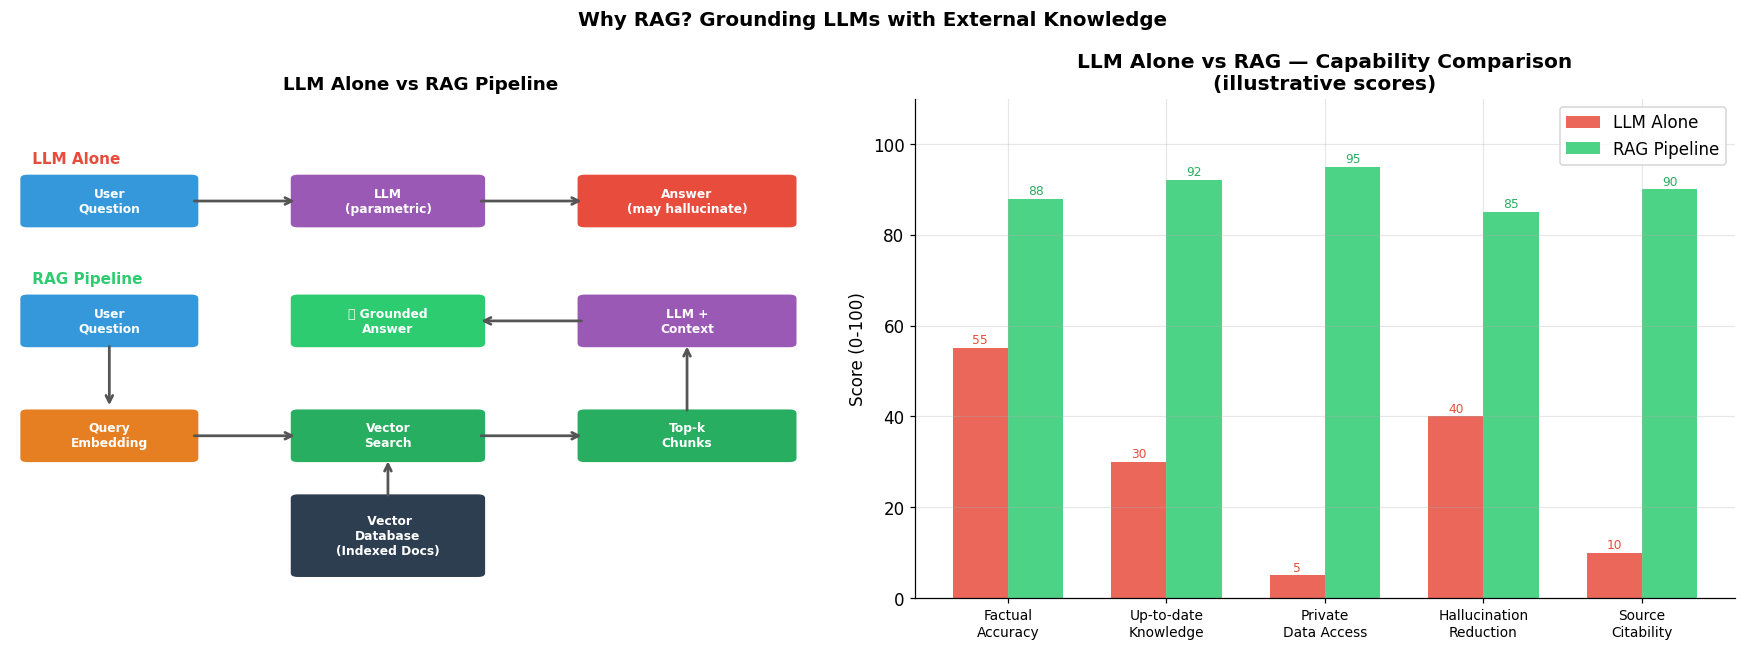

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as FancyBboxPatch
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: LLM alone vs RAG comparison 
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('LLM Alone vs RAG Pipeline', fontweight='bold', fontsize=12)

# LLM alone (top)
def draw_box(ax, x, y, w, h, text, color, fontsize=9, text_color='white'):
    b = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                        facecolor=color, edgecolor='white', linewidth=1.5, zorder=3)
    ax.add_patch(b)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center',
             fontsize=fontsize, color=text_color, fontweight='bold', zorder=4)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                 arrowprops=dict(arrowstyle='->', color='#555', lw=1.8), zorder=5)

# LLM Alone row
ax.text(0.2, 8.7, ' LLM Alone', fontsize=10, fontweight='bold', color='#e74c3c')
draw_box(ax, 0.2, 7.5, 2.0, 0.9, 'User\nQuestion', '#3498db', fontsize=8)
draw_arrow(ax, 2.2, 7.95, 3.5, 7.95)
draw_box(ax, 3.5, 7.5, 2.2, 0.9, 'LLM\n(parametric)', '#9b59b6', fontsize=8)
draw_arrow(ax, 5.7, 7.95, 7.0, 7.95)
draw_box(ax, 7.0, 7.5, 2.5, 0.9, 'Answer\n(may hallucinate)', '#e74c3c', fontsize=8)

# RAG row
ax.text(0.2, 6.3, ' RAG Pipeline', fontsize=10, fontweight='bold', color='#2ecc71')
draw_box(ax, 0.2, 5.1, 2.0, 0.9, 'User\nQuestion', '#3498db', fontsize=8)
draw_arrow(ax, 1.2, 5.1, 1.2, 3.8)
draw_box(ax, 0.2, 2.8, 2.0, 0.9, 'Query\nEmbedding', '#e67e22', fontsize=8)
draw_arrow(ax, 2.2, 3.25, 3.5, 3.25)
draw_box(ax, 3.5, 2.8, 2.2, 0.9, 'Vector\nSearch', '#27ae60', fontsize=8)
draw_arrow(ax, 5.7, 3.25, 7.0, 3.25)
draw_box(ax, 7.0, 2.8, 2.5, 0.9, 'Top-k\nChunks', '#27ae60', fontsize=8)
draw_arrow(ax, 8.25, 3.7, 8.25, 5.1)
draw_box(ax, 7.0, 5.1, 2.5, 0.9, 'LLM +\nContext', '#9b59b6', fontsize=8)
draw_arrow(ax, 7.0, 5.55, 5.7, 5.55)
draw_box(ax, 3.5, 5.1, 2.2, 0.9, '✅ Grounded\nAnswer', '#2ecc71', fontsize=8)

# Vector DB
draw_box(ax, 3.5, 0.5, 2.2, 1.5, ' Vector\nDatabase\n(Indexed Docs)', '#2c3e50', fontsize=8)
draw_arrow(ax, 4.6, 2.0, 4.6, 2.8)

# ── Right: RAG benefits bar chart ────────────────────────────
ax2 = axes[1]
categories = ['Factual\nAccuracy', 'Up-to-date\nKnowledge', 'Private\nData Access',
               'Hallucination\nReduction', 'Source\nCitability']
llm_alone  = [55, 30, 5,  40, 10]
rag_scores = [88, 92, 95, 85, 90]

x = np.arange(len(categories))
w = 0.35
bars1 = ax2.bar(x - w/2, llm_alone,  w, label='LLM Alone',    color='#e74c3c', alpha=0.85)
bars2 = ax2.bar(x + w/2, rag_scores, w, label='RAG Pipeline', color='#2ecc71', alpha=0.85)

for b in bars1:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1,
              f'{b.get_height()}', ha='center', fontsize=8, color='#e74c3c')
for b in bars2:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1,
              f'{b.get_height()}', ha='center', fontsize=8, color='#27ae60')

ax2.set_xticks(x); ax2.set_xticklabels(categories, fontsize=9)
ax2.set_ylim(0, 110); ax2.set_ylabel('Score (0-100)')
ax2.set_title('LLM Alone vs RAG — Capability Comparison\n(illustrative scores)', fontweight='bold')
ax2.legend()

plt.suptitle('Why RAG? Grounding LLMs with External Knowledge', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2: Text Chunking Strategies

**Chunking** is the process of splitting large documents into smaller pieces that can be embedded and retrieved independently. It's one of the most impactful design decisions in a RAG system.

### Why Chunking Matters
- **Too large** → Noisy retrieval; irrelevant context dilutes the answer
- **Too small** → Missing context; splits sentences that belong together
- **Just right** → Semantically coherent units that match query granularity

### Chunking Strategies
| Strategy | Method | Best For |
|---|---|---|
| **Fixed Size** | Split every N tokens/chars | Simple baseline |
| **Fixed + Overlap** | N tokens with M overlap | Preserves context at boundaries |
| **Sentence** | Split on `.`, `?`, `!` | Conversational text |
| **Recursive** | Split by `\n\n` → `\n` → `.` → chars | Structured documents |
| **Semantic** | Split when embedding cosine similarity drops | Best quality, slower |
| **Document-aware** | Split on Markdown headers, HTML tags | Code docs, wikis |

In [15]:

# sample corpus (about AI topics) 
SAMPLE_CORPUS = """
Artificial intelligence (AI) is the simulation of human intelligence processes by machines,
especially computer systems. These processes include learning, reasoning, and self-correction.
AI was founded as an academic discipline in 1956 and has experienced several waves of optimism.

Machine learning is a subset of AI that gives computers the ability to learn without being
explicitly programmed. It focuses on developing computer programs that can access data and
use it to learn for themselves. The process begins with observations or data, such as examples,
direct experience, or instruction.

Deep learning is part of a broader family of machine learning methods based on artificial
neural networks with representation learning. Learning can be supervised, semi-supervised
or unsupervised. Deep learning architectures such as deep neural networks, recurrent neural
networks, and convolutional neural networks have been applied to many domains.

Natural language processing (NLP) is a subfield of linguistics, computer science, and AI
concerned with the interactions between computers and human language. In particular, it
focuses on how to program computers to process and analyze large amounts of natural language data.
Challenges in NLP frequently involve speech recognition, natural language understanding,
and natural language generation.

Large language models (LLMs) are AI systems trained on massive text corpora. They can generate
coherent text, answer questions, write code, and perform a wide variety of language tasks.
Examples include GPT-4, Claude, Gemini, and LLaMA. These models use transformer architectures
with attention mechanisms that allow them to capture long-range dependencies in text.

Transformer architecture was introduced in the paper 'Attention Is All You Need' in 2017.
It relies entirely on attention mechanisms, dispensing with recurrence and convolutions.
The transformer has become the dominant architecture for NLP tasks and has been extended
to vision (ViT), audio, and multimodal domains.

Retrieval-Augmented Generation (RAG) combines information retrieval with language generation.
A retriever fetches relevant documents from a knowledge base, and a generator produces
answers conditioned on both the query and retrieved documents. This approach reduces
hallucinations and allows models to access up-to-date information beyond their training data.

Vector databases store and index high-dimensional embeddings for fast similarity search.
Common examples include FAISS, Pinecone, Weaviate, Chroma, and Qdrant. They use approximate
nearest neighbour (ANN) algorithms such as HNSW and IVF to enable sub-millisecond search
across millions of vectors.
"""

# strategy 1: Fixed-size chunking 
def chunk_fixed(text: str, chunk_size: int = 200, overlap: int = 0) -> List[str]:
    """Split text into fixed-size character chunks."""
    words  = text.split()
    chunks = []
    step   = max(1, chunk_size - overlap)
    for i in range(0, len(words), step):
        chunk = ' '.join(words[i:i+chunk_size])
        if chunk.strip():
            chunks.append(chunk.strip())
        if i + chunk_size >= len(words):
            break
    return chunks

# strategy 2: Sentence-based chunking
def chunk_sentences(text: str, sentences_per_chunk: int = 3) -> List[str]:
    """Split on sentence boundaries."""
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    chunks    = []
    for i in range(0, len(sentences), sentences_per_chunk):
        chunk = ' '.join(sentences[i:i+sentences_per_chunk])
        if chunk:
            chunks.append(chunk)
    return chunks

# strategy 3: Recursive paragraph chunking 
def chunk_recursive(text: str, max_chars: int = 400) -> List[str]:
    """
    Recursively split: paragraphs → sentences → words.
    Mimics LangChain's RecursiveCharacterTextSplitter.
    """
    separators = ['\n\n', '\n', '. ', ' ']

    def _split(text: str, seps: List[str]) -> List[str]:
        if not seps or len(text) <= max_chars:
            return [text.strip()] if text.strip() else []
        sep    = seps[0]
        parts  = text.split(sep)
        chunks = []
        current = ''
        for part in parts:
            candidate = (current + sep + part).strip() if current else part.strip()
            if len(candidate) <= max_chars:
                current = candidate
            else:
                if current:
                    chunks.append(current)
                if len(part) > max_chars:
                    chunks.extend(_split(part, seps[1:]))
                    current = ''
                else:
                    current = part.strip()
        if current:
            chunks.append(current)
        return [c for c in chunks if c]

    return _split(text, separators)

# strategy 4: Token-aware chunking
def chunk_by_tokens(text: str, max_tokens: int = 100, overlap: int = 20) -> List[str]:
    """Rough token-aware chunking (1 token ≈ 4 chars)."""
    words       = text.split()
    token_est   = [len(w) // 4 + 1 for w in words]
    chunks, cur_words, cur_tokens = [], [], 0

    for word, tok in zip(words, token_est):
        if cur_tokens + tok > max_tokens and cur_words:
            chunks.append(' '.join(cur_words))
            # Keep overlap
            overlap_words = cur_words[-overlap:] if overlap else []
            cur_words  = overlap_words + [word]
            cur_tokens = sum(len(w)//4+1 for w in cur_words)
        else:
            cur_words.append(word)
            cur_tokens += tok

    if cur_words:
        chunks.append(' '.join(cur_words))
    return [c.strip() for c in chunks if c.strip()]


# compare all strategies
strategies = {
    'Fixed-50w':       chunk_fixed(SAMPLE_CORPUS, 50, 0),
    'Fixed+Overlap':   chunk_fixed(SAMPLE_CORPUS, 50, 10),
    'Sentence (3)':    chunk_sentences(SAMPLE_CORPUS, 3),
    'Recursive-400c':  chunk_recursive(SAMPLE_CORPUS, 400),
    'Token-100':       chunk_by_tokens(SAMPLE_CORPUS, 100, 20),
}

print(' Chunking Strategy Comparison:')
print(f'{"Strategy":<20}  {"# Chunks":<10}  {"Avg Len (chars)":<18}  {"Min":<6}  {"Max"}')
print('─' * 65)
for name, chunks in strategies.items():
    lens = [len(c) for c in chunks]
    print(f'{name:<20}  {len(chunks):<10}  {np.mean(lens):<18.0f}  {min(lens):<6}  {max(lens)}')

print(f'\n Sample chunk from Recursive strategy:')
print('  "' + strategies['Recursive-400c'][2][:150] + '..."')

 Chunking Strategy Comparison:
Strategy              # Chunks    Avg Len (chars)     Min     Max
─────────────────────────────────────────────────────────────────
Fixed-50w             8           335                 177     378
Fixed+Overlap         10          331                 98      381
Sentence (3)          9           297                 137     397
Recursive-400c        8           335                 282     397
Token-100             14          320                 157     344

 Sample chunk from Recursive strategy:
  "Deep learning is part of a broader family of machine learning methods based on artificial
neural networks with representation learning. Learning can b..."


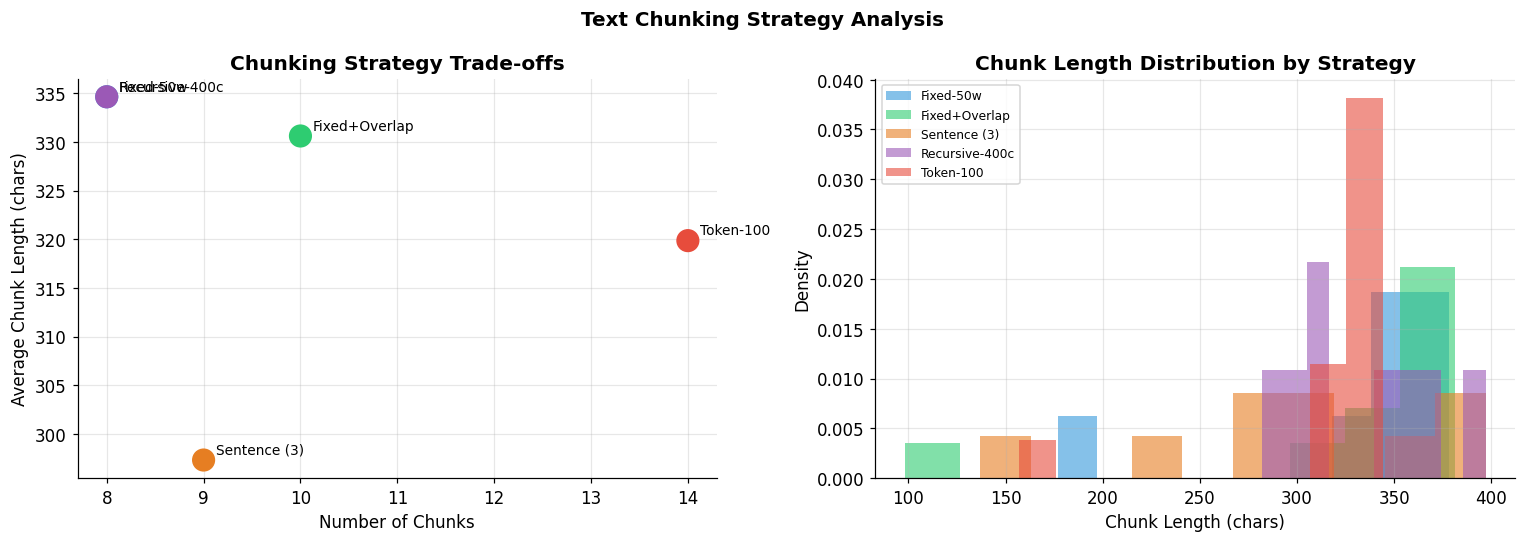

In [16]:
# Visualise chunking strategies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chunk count vs avg length
names    = list(strategies.keys())
n_chunks = [len(v) for v in strategies.values()]
avg_lens = [np.mean([len(c) for c in v]) for v in strategies.values()]
colors_s = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c']

scatter = axes[0].scatter(n_chunks, avg_lens, c=colors_s, s=200, zorder=5)
for i, name in enumerate(names):
    axes[0].annotate(name, (n_chunks[i], avg_lens[i]),
                      textcoords='offset points', xytext=(8, 4), fontsize=9)
axes[0].set_xlabel('Number of Chunks')
axes[0].set_ylabel('Average Chunk Length (chars)')
axes[0].set_title('Chunking Strategy Trade-offs', fontweight='bold')

# Length distribution per strategy
for name, color in zip(names, colors_s):
    lengths = [len(c) for c in strategies[name]]
    axes[1].hist(lengths, bins=10, alpha=0.6, color=color, label=name, density=True)

axes[1].set_xlabel('Chunk Length (chars)')
axes[1].set_ylabel('Density')
axes[1].set_title('Chunk Length Distribution by Strategy', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Text Chunking Strategy Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3: Embeddings : Turning Text into Vectors

**Embeddings** map text to dense vectors in a high-dimensional space where **semantic similarity = geometric proximity**.

### Why Embeddings?
```
Keyword search: "dog" does NOT match "canine"
Embedding search: embed("dog") ≈ embed("canine")  ✅
```

### Key Properties of Good Embeddings
| Property | Description |
|---|---|
| **Semantic similarity** | Similar meanings → nearby vectors |
| **Isotropy** | Vectors spread uniformly, not clustered in one region |
| **Contextual** | Same word, different context → different vectors |
| **Dimensionality** | 384–3072 dims (trade-off: quality vs speed) |

### Popular Embedding Models
| Model | Dims | Notes |
|---|---|---|
| `all-MiniLM-L6-v2` | 384 | Fast, great for CPU |
| `all-mpnet-base-v2` | 768 | Best quality in sentence-transformers |
| `text-embedding-ada-002` | 1536 | OpenAI, high quality |
| `e5-large-v2` | 1024 | State-of-the-art open source |
| `nomic-embed-text` | 768 | Efficient, open weights |

In [17]:

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

print(' Loading embedding model (downloads on first run)...')
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f' Model loaded: all-MiniLM-L6-v2')
print(f'   Embedding dimension: {embed_model.get_sentence_embedding_dimension()}')

# ── Embed our corpus chunks ───────────────────────────────────
CHUNKS   = strategies['Recursive-400c']   # use recursive chunks
CHUNKS   = [c for c in CHUNKS if len(c) > 50][:20]  # keep top 20

print(f'\n Embedding {len(CHUNKS)} chunks...')
t0 = time.time()
chunk_embeddings = embed_model.encode(CHUNKS, show_progress_bar=True,
                                       convert_to_numpy=True,
                                       normalize_embeddings=True)
t1 = time.time()
print(f' Embedded in {t1-t0:.2f}s')
print(f'   Shape: {chunk_embeddings.shape}  ({len(CHUNKS)} chunks × 384 dims)')

# ── Semantic similarity matrix ────────────────────────────────
sim_matrix = cosine_similarity(chunk_embeddings)

print('\n Top-3 most similar chunk pairs:')
pairs = []
for i in range(len(CHUNKS)):
    for j in range(i+1, len(CHUNKS)):
        pairs.append((sim_matrix[i,j], i, j))
pairs.sort(reverse=True)
for score, i, j in pairs[:3]:
    print(f'  [{score:.3f}] Chunk {i}: "{CHUNKS[i][:60]}..."')
    print(f'         Chunk {j}: "{CHUNKS[j][:60]}..."')
    print()

 Loading embedding model (downloads on first run)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Model loaded: all-MiniLM-L6-v2
   Embedding dimension: 384

 Embedding 8 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

 Embedded in 0.03s
   Shape: (8, 384)  (8 chunks × 384 dims)

 Top-3 most similar chunk pairs:
  [0.626] Chunk 0: "Artificial intelligence (AI) is the simulation of human inte..."
         Chunk 1: "Machine learning is a subset of AI that gives computers the ..."

  [0.491] Chunk 1: "Machine learning is a subset of AI that gives computers the ..."
         Chunk 2: "Deep learning is part of a broader family of machine learnin..."

  [0.434] Chunk 4: "Large language models (LLMs) are AI systems trained on massi..."
         Chunk 5: "Transformer architecture was introduced in the paper 'Attent..."



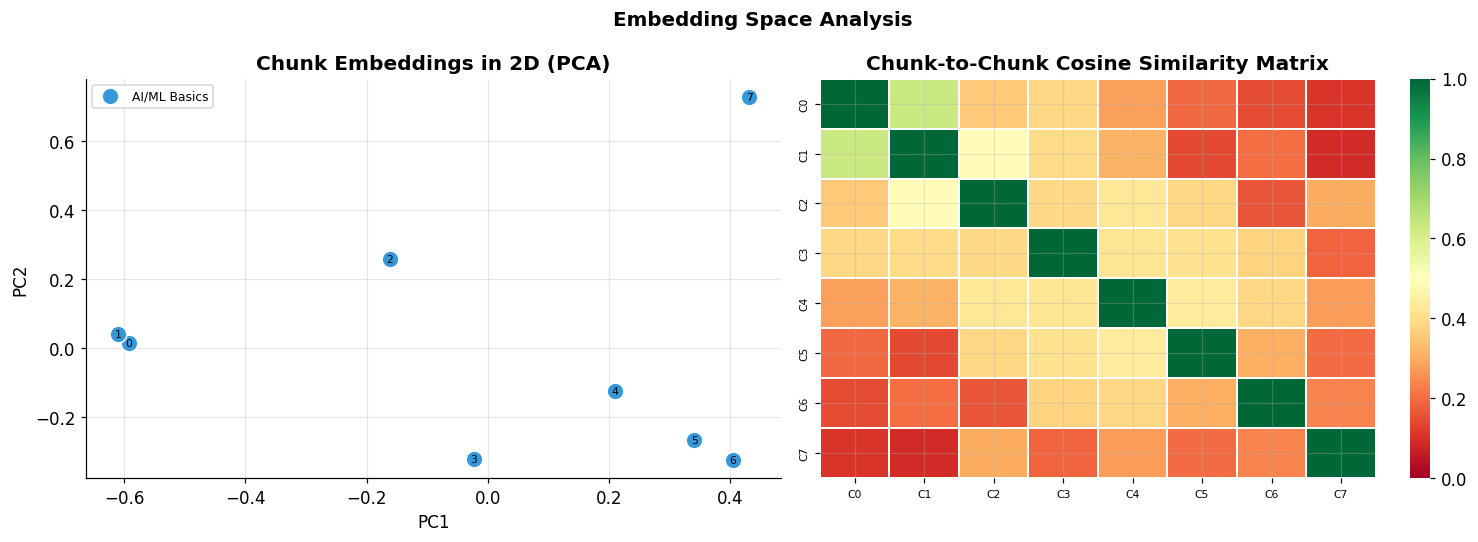

In [18]:
# Visualise Embeddings 
# Assign topic labels to chunks
topic_keywords = {
    'AI/ML Basics':    ['artificial intelligence', 'machine learning', 'AI'],
    'Deep Learning':   ['deep learning', 'neural networks', 'convolutional'],
    'NLP/LLMs':        ['natural language', 'NLP', 'language model', 'transformer'],
    'RAG/Vectors':     ['retrieval', 'vector', 'RAG', 'embedding', 'database'],
}
topic_colors = {'AI/ML Basics':'#3498db','Deep Learning':'#e74c3c','NLP/LLMs':'#2ecc71','RAG/Vectors':'#9b59b6','Other':'#95a5a6'}

def assign_topic(chunk):
    chunk_lower = chunk.lower()
    for topic, kws in topic_keywords.items():
        if any(kw.lower() in chunk_lower for kw in kws):
            return topic
    return 'Other'

labels = [assign_topic(c) for c in CHUNKS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA projection
pca_2d = PCA(n_components=2).fit_transform(chunk_embeddings)
for topic, color in topic_colors.items():
    idx = [i for i,l in enumerate(labels) if l == topic]
    if idx:
        axes[0].scatter(pca_2d[idx,0], pca_2d[idx,1],
                         c=color, label=topic, s=120, zorder=5, edgecolors='white', linewidth=1)
for i, chunk in enumerate(CHUNKS):
    axes[0].annotate(str(i), (pca_2d[i,0], pca_2d[i,1]),
                      fontsize=7, ha='center', va='center', zorder=6, color='black')
axes[0].set_title('Chunk Embeddings in 2D (PCA)', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8, loc='best')

# Cosine similarity heatmap
sns.heatmap(sim_matrix, cmap='RdYlGn', center=0.5,
             xticklabels=[f'C{i}' for i in range(len(CHUNKS))],
             yticklabels=[f'C{i}' for i in range(len(CHUNKS))],
             ax=axes[1], linewidths=0.3, vmin=0, vmax=1)
axes[1].set_title('Chunk-to-Chunk Cosine Similarity Matrix', fontweight='bold')
axes[1].tick_params(labelsize=7)

plt.suptitle('Embedding Space Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4: Vector Stores & Similarity Search

A **vector store** (or vector database) stores embeddings and enables fast **approximate nearest neighbour (ANN)** search.

### FAISS : Facebook AI Similarity Search
FAISS is the most widely used open-source vector library. Key indexes:

| Index | Method | Speed | Accuracy | Memory |
|---|---|---|---|---|
| `IndexFlatL2` | Exact brute-force (L2) | Slow | 100% | High |
| `IndexFlatIP` | Exact brute-force (Inner Product) | Slow | 100% | High |
| `IndexIVFFlat` | Inverted file index (approximate) | Fast | ~95% | Medium |
| `IndexHNSWFlat` | Hierarchical Navigable Small World | Very fast | ~99% | High |
| `IndexIVFPQ` | IVF + Product Quantisation | Fastest | ~90% | Low |

### Similarity Metrics
```
Cosine Similarity:    cos(θ) = (A·B) / (||A|| ||B||)   → [−1, 1]
Dot Product:          A·B = Σ aᵢ·bᵢ                    → (−∞, ∞)
Euclidean (L2):       ||A−B|| = √Σ(aᵢ−bᵢ)²             → [0, ∞)
```
> For normalised vectors: cosine similarity = dot product

In [19]:
# Section 4 — Vector Store with FAISS
import faiss
import numpy as np

DIM = chunk_embeddings.shape[1]   # 384

# Build a simple FAISS vector store
class SimpleVectorStore:
    """
    A minimal vector store wrapping FAISS.
    Stores: embeddings + original text + metadata.
    """
    def __init__(self, dim: int, index_type: str = 'flat'):
        self.dim    = dim
        self.texts  = []
        self.metadata = []

        if index_type == 'flat':
            self.index = faiss.IndexFlatIP(dim)  # Inner product (cosine for normalised)
        elif index_type == 'hnsw':
            self.index = faiss.IndexHNSWFlat(dim, 32)  # 32 = M parameter
            self.index.hnsw.efConstruction = 64
        else:
            self.index = faiss.IndexFlatL2(dim)

    def add(self, texts: List[str], embeddings: np.ndarray,
             metadata: Optional[List[dict]] = None):
        """Add vectors and their corresponding texts."""
        vecs = embeddings.astype(np.float32)
        faiss.normalize_L2(vecs)  # Ensure normalised for cosine similarity
        self.index.add(vecs)
        self.texts.extend(texts)
        self.metadata.extend(metadata or [{}] * len(texts))
        return self

    def search(self, query_embedding: np.ndarray, k: int = 5) -> List[dict]:
        """Return top-k most similar documents."""
        q   = query_embedding.reshape(1, -1).astype(np.float32)
        faiss.normalize_L2(q)
        scores, indices = self.index.search(q, k)
        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx >= 0:
                results.append({
                    'text':     self.texts[idx],
                    'score':    float(score),
                    'index':    int(idx),
                    'metadata': self.metadata[idx]
                })
        return results

    def __len__(self):
        return self.index.ntotal


# populate the vector store 
vs = SimpleVectorStore(dim=DIM, index_type='flat')
meta = [{'chunk_id': i, 'source': 'ai_corpus', 'length': len(c)} for i, c in enumerate(CHUNKS)]
vs.add(CHUNKS, chunk_embeddings, meta)

print(f' Vector Store created')
print(f'   Index type : FAISS FlatIP (exact cosine)')
print(f'   Vectors    : {len(vs)}')
print(f'   Dimension  : {DIM}')

# test search 
TEST_QUERIES = [
    'What are large language models?',
    'How does vector similarity search work?',
    'What is the transformer architecture?'
]

print('\n Test Retrieval:')
for query in TEST_QUERIES:
    q_emb = embed_model.encode([query], normalize_embeddings=True)
    results = vs.search(q_emb[0], k=2)
    print(f'\n  Query: "{query}"')
    for r in results:
        print(f'  [{r["score"]:.3f}] {r["text"][:100]}...')

 Vector Store created
   Index type : FAISS FlatIP (exact cosine)
   Vectors    : 8
   Dimension  : 384

 Test Retrieval:

  Query: "What are large language models?"
  [0.715] Large language models (LLMs) are AI systems trained on massive text corpora. They can generate
coher...
  [0.372] Natural language processing (NLP) is a subfield of linguistics, computer science, and AI
concerned w...

  Query: "How does vector similarity search work?"
  [0.701] Vector databases store and index high-dimensional embeddings for fast similarity search.
Common exam...
  [0.238] Retrieval-Augmented Generation (RAG) combines information retrieval with language generation.
A retr...

  Query: "What is the transformer architecture?"
  [0.505] Transformer architecture was introduced in the paper 'Attention Is All You Need' in 2017.
It relies ...
  [0.275] Deep learning is part of a broader family of machine learning methods based on artificial
neural net...


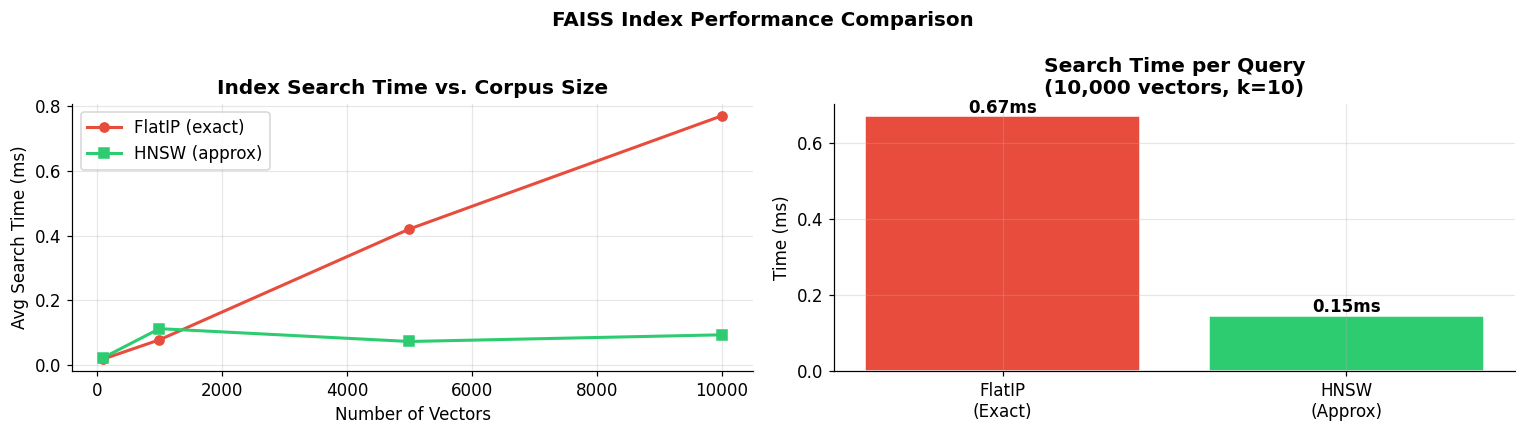

 Speed-up from HNSW: 4.6x faster than Flat search


In [20]:
# benchmark: Flat vs HNSW index speed
# Create a larger synthetic embedding set
N_LARGE   = 10_000
DIM_LARGE = 384
synthetic_vecs = np.random.randn(N_LARGE, DIM_LARGE).astype(np.float32)
faiss.normalize_L2(synthetic_vecs)

q_bench = np.random.randn(100, DIM_LARGE).astype(np.float32)
faiss.normalize_L2(q_bench)

# Flat index
idx_flat = faiss.IndexFlatIP(DIM_LARGE)
idx_flat.add(synthetic_vecs)
t0 = time.time()
for q in q_bench:
    idx_flat.search(q.reshape(1,-1), 10)
flat_time = (time.time() - t0) / 100 * 1000

# HNSW index
idx_hnsw = faiss.IndexHNSWFlat(DIM_LARGE, 32)
idx_hnsw.add(synthetic_vecs)
t0 = time.time()
for q in q_bench:
    idx_hnsw.search(q.reshape(1,-1), 10)
hnsw_time = (time.time() - t0) / 100 * 1000

# Index sizes
sizes    = [100, 1_000, 5_000, 10_000]
times_flat = []; times_hnsw = []
for n in sizes:
    v = synthetic_vecs[:n]
    q_t = q_bench[:10]
    # Flat
    ix = faiss.IndexFlatIP(DIM_LARGE); ix.add(v)
    t = time.time()
    for qq in q_t: ix.search(qq.reshape(1,-1), 10)
    times_flat.append((time.time()-t)/10*1000)
    # HNSW
    ix2 = faiss.IndexHNSWFlat(DIM_LARGE, 16); ix2.add(v)
    t = time.time()
    for qq in q_t: ix2.search(qq.reshape(1,-1), 10)
    times_hnsw.append((time.time()-t)/10*1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(sizes, times_flat, 'o-', color='#e74c3c', linewidth=2, label='FlatIP (exact)')
axes[0].plot(sizes, times_hnsw, 's-', color='#2ecc71', linewidth=2, label='HNSW (approx)')
axes[0].set_title('Index Search Time vs. Corpus Size', fontweight='bold')
axes[0].set_xlabel('Number of Vectors'); axes[0].set_ylabel('Avg Search Time (ms)')
axes[0].legend()

bar_data = {'FlatIP\n(Exact)': flat_time, 'HNSW\n(Approx)': hnsw_time}
bars = axes[1].bar(bar_data.keys(), bar_data.values(),
                    color=['#e74c3c','#2ecc71'], edgecolor='white')
for b in bars:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                  f'{b.get_height():.2f}ms', ha='center', fontweight='bold')
axes[1].set_title(f'Search Time per Query\n({N_LARGE:,} vectors, k=10)', fontweight='bold')
axes[1].set_ylabel('Time (ms)')

plt.suptitle('FAISS Index Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f' Speed-up from HNSW: {flat_time/hnsw_time:.1f}x faster than Flat search')

---
## Section 5: Building a Naive RAG Pipeline

Now we assemble the first complete RAG pipeline. Naive RAG follows a simple **Retrieve → Read** pattern:

```
1. Offline indexing:
   Documents → Chunk → Embed → Store in Vector DB

2. Online querying:
   Query → Embed → Search → Top-k Chunks → LLM → Answer
```

We'll use a **local Flan-T5 model** so no API key is needed. You can swap this for any LLM (GPT-4, Claude, Mistral, etc.).

In [21]:
# Section 5 — Naive RAG Pipeline

from transformers import pipeline as hf_pipeline


generator = hf_pipeline(
    'text-generation',
    model='google/flan-t5-base',
    max_new_tokens=200,
    do_sample=False
)
print(' LLM loaded')


# RAG Components
class NaiveRAG:
    """
    A minimal Retrieve-then-Read RAG pipeline.

    Components:
      Retriever   : Embedding model + FAISS vector store
      Reader/Gen  : Local LLM (Flan-T5)
    """
    def __init__(self, vector_store: SimpleVectorStore,
                 embed_model, generator,
                 top_k: int = 3):
        self.vs        = vector_store
        self.embedder  = embed_model
        self.generator = generator
        self.top_k     = top_k

    def retrieve(self, query: str) -> List[dict]:
        """Step 1: Embed query → search vector store."""
        q_emb = self.embedder.encode([query], normalize_embeddings=True)
        return self.vs.search(q_emb[0], k=self.top_k)

    def build_prompt(self, query: str, contexts: List[dict]) -> str:
        """Step 2: Build a RAG prompt from query + retrieved docs."""
        context_text = '\n'.join(
            [f'[Doc {i+1}]: {c["text"]}' for i, c in enumerate(contexts)]
        )
        return (
            f'Answer the following question using ONLY the provided context.\n\n'
            f'Context:\n{context_text}\n\n'
            f'Question: {query}\n\n'
            f'Answer:'
        )

    def generate(self, prompt: str) -> str:
        """Step 3: LLM generates answer from prompt."""
        result = self.generator(prompt)[0]['generated_text']
        return result.strip()

    def answer(self, query: str, verbose: bool = False) -> dict:
        """Full RAG pipeline: query → retrieved docs → LLM → answer."""
        t0       = time.time()
        contexts = self.retrieve(query)
        t_ret    = time.time() - t0

        prompt   = self.build_prompt(query, contexts)
        t0       = time.time()
        answer   = self.generate(prompt)
        t_gen    = time.time() - t0

        if verbose:
            print(f'\n📨 Query: "{query}"')
            print(f'\n📚 Retrieved {len(contexts)} chunks (in {t_ret*1000:.1f}ms):')
            for i, ctx in enumerate(contexts):
                print(f'  [{ctx["score"]:.3f}] {ctx["text"][:100]}...')
            print(f'\n💬 Answer (generated in {t_gen*1000:.0f}ms):\n  {answer}')

        return {
            'query':    query,
            'contexts': contexts,
            'prompt':   prompt,
            'answer':   answer,
            'retrieval_time_ms': t_ret * 1000,
            'gen_time_ms':       t_gen * 1000
        }


rag = NaiveRAG(vs, embed_model, generator, top_k=3)

#  Test queries
test_qs = [
    'What is RAG and how does it work?',
    'What year was the transformer architecture introduced?',
    'Name some examples of large language models.',
]


print('  NAIVE RAG PIPELINE — TEST QUERIES')

rag_results = []
for q in test_qs:
    res = rag.answer(q, verbose=True)
    rag_results.append(res)
    print('─'*65)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl

 LLM loaded
  NAIVE RAG PIPELINE — TEST QUERIES


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📨 Query: "What is RAG and how does it work?"

📚 Retrieved 3 chunks (in 8.0ms):
  [0.363] Retrieval-Augmented Generation (RAG) combines information retrieval with language generation.
A retr...
  [0.076] Natural language processing (NLP) is a subfield of linguistics, computer science, and AI
concerned w...
  [0.069] Machine learning is a subset of AI that gives computers the ability to learn without being
explicitl...

💬 Answer (generated in 454ms):
  Answer the following question using ONLY the provided context.

Context:
[Doc 1]: Retrieval-Augmented Generation (RAG) combines information retrieval with language generation.
A retriever fetches relevant documents from a knowledge base, and a generator produces
answers conditioned on both the query and retrieved documents. This approach reduces
hallucinations and allows models to access up-to-date information beyond their training data.
[Doc 2]: Natural language processing (NLP) is a subfield of linguistics, computer science, and AI
conc

---
## Section 6: Advanced Retrieval : Re-ranking & Hybrid Search

Naive RAG retrieves by **embedding similarity alone**. Advanced RAG adds two key improvements:

### 1. Hybrid Search (Sparse + Dense)
```
Dense:   Embedding similarity → captures semantic meaning
Sparse:  BM25 (keyword)       → captures exact term matching
Hybrid:  RRF(dense, sparse)   → best of both worlds
```

**Reciprocal Rank Fusion (RRF):**
```
RRF_score(doc) = Σ_r  1 / (k + rank_r(doc))
where k = 60  (smoothing constant)
```

### 2. Cross-Encoder Re-ranking
After retrieving top-k candidates, a **cross-encoder** model re-scores them by reading query + document together:
```
Bi-encoder (retrieval):    encode(query) ⊙ encode(doc)  → fast, less accurate
Cross-encoder (reranking): encode([query, doc])          → slow, more accurate
```
Typical pipeline: retrieve 20 candidates → rerank → keep top 3

In [22]:

# Section 6 — Hybrid Search (BM25 + Dense) with RRF

from rank_bm25 import BM25Okapi

#  BM25 (sparse retriever)
class BM25Retriever:
    """Sparse retriever using BM25 keyword matching."""
    def __init__(self, texts: List[str]):
        tokenized = [self._tokenize(t) for t in texts]
        self.bm25  = BM25Okapi(tokenized)
        self.texts = texts

    def _tokenize(self, text: str) -> List[str]:
        return re.sub(r'[^a-z0-9 ]', '', text.lower()).split()

    def search(self, query: str, k: int = 10) -> List[dict]:
        tokens = self._tokenize(query)
        scores = self.bm25.get_scores(tokens)
        ranked = np.argsort(scores)[::-1][:k]
        return [{'text': self.texts[i], 'score': float(scores[i]), 'index': int(i)}
                for i in ranked]


#Reciprocal Rank Fusion 
def reciprocal_rank_fusion(result_lists: List[List[dict]],
                            k: int = 60) -> List[dict]:
    """
    Merge multiple ranked lists using RRF.
    Each doc's score = sum(1 / (k + rank)) across all lists.
    """
    scores  = defaultdict(float)
    doc_map = {}

    for result_list in result_lists:
        for rank, doc in enumerate(result_list):
            key = doc['index']
            scores[key]  += 1.0 / (k + rank + 1)
            doc_map[key]  = doc

    sorted_keys = sorted(scores, key=lambda x: scores[x], reverse=True)
    return [{'text': doc_map[k]['text'],
             'score': scores[k],
             'index': k,
             'metadata': doc_map[k].get('metadata', {})
            } for k in sorted_keys]


#  Hybrid Retriever 
class HybridRetriever:
    """Combines dense (embedding) and sparse (BM25) retrieval."""
    def __init__(self, texts, embeddings, embed_model, dim):
        self.dense   = SimpleVectorStore(dim, 'flat')
        self.dense.add(texts, embeddings)
        self.sparse  = BM25Retriever(texts)
        self.embedder = embed_model
        self.texts    = texts

    def retrieve(self, query: str, k: int = 5,
                  n_candidates: int = 10) -> List[dict]:
        q_emb    = self.embedder.encode([query], normalize_embeddings=True)
        dense_r  = self.dense.search(q_emb[0], k=n_candidates)
        sparse_r = self.sparse.search(query, k=n_candidates)
        fused    = reciprocal_rank_fusion([dense_r, sparse_r])
        return fused[:k]


hybrid_ret = HybridRetriever(CHUNKS, chunk_embeddings, embed_model, DIM)
bm25_ret   = BM25Retriever(CHUNKS)

# ── Compare Dense vs BM25 vs Hybrid ──────────────────────────
query_compare = 'How do transformers and attention mechanisms work?'

q_emb    = embed_model.encode([query_compare], normalize_embeddings=True)
dense_r  = vs.search(q_emb[0], k=5)
sparse_r = bm25_ret.search(query_compare, k=5)
hybrid_r = hybrid_ret.retrieve(query_compare, k=5)

print(f'🔍 Query: "{query_compare}"\n')
for method_name, results in [('Dense (embedding)', dense_r),
                               ('Sparse (BM25)',     sparse_r),
                               ('Hybrid (RRF)',       hybrid_r)]:
    print(f'  ── {method_name} ──')
    for r in results[:3]:
        print(f'  [{r["score"]:6.4f}] {r["text"][:100]}...')
    print()

🔍 Query: "How do transformers and attention mechanisms work?"

  ── Dense (embedding) ──
  [0.6363] Transformer architecture was introduced in the paper 'Attention Is All You Need' in 2017.
It relies ...
  [0.2530] Large language models (LLMs) are AI systems trained on massive text corpora. They can generate
coher...
  [0.2320] Deep learning is part of a broader family of machine learning methods based on artificial
neural net...

  ── Sparse (BM25) ──
  [2.9223] Transformer architecture was introduced in the paper 'Attention Is All You Need' in 2017.
It relies ...
  [2.2750] Large language models (LLMs) are AI systems trained on massive text corpora. They can generate
coher...
  [2.0586] Natural language processing (NLP) is a subfield of linguistics, computer science, and AI
concerned w...

  ── Hybrid (RRF) ──
  [0.0328] Transformer architecture was introduced in the paper 'Attention Is All You Need' in 2017.
It relies ...
  [0.0323] Large language models (LLMs) are AI systems traine

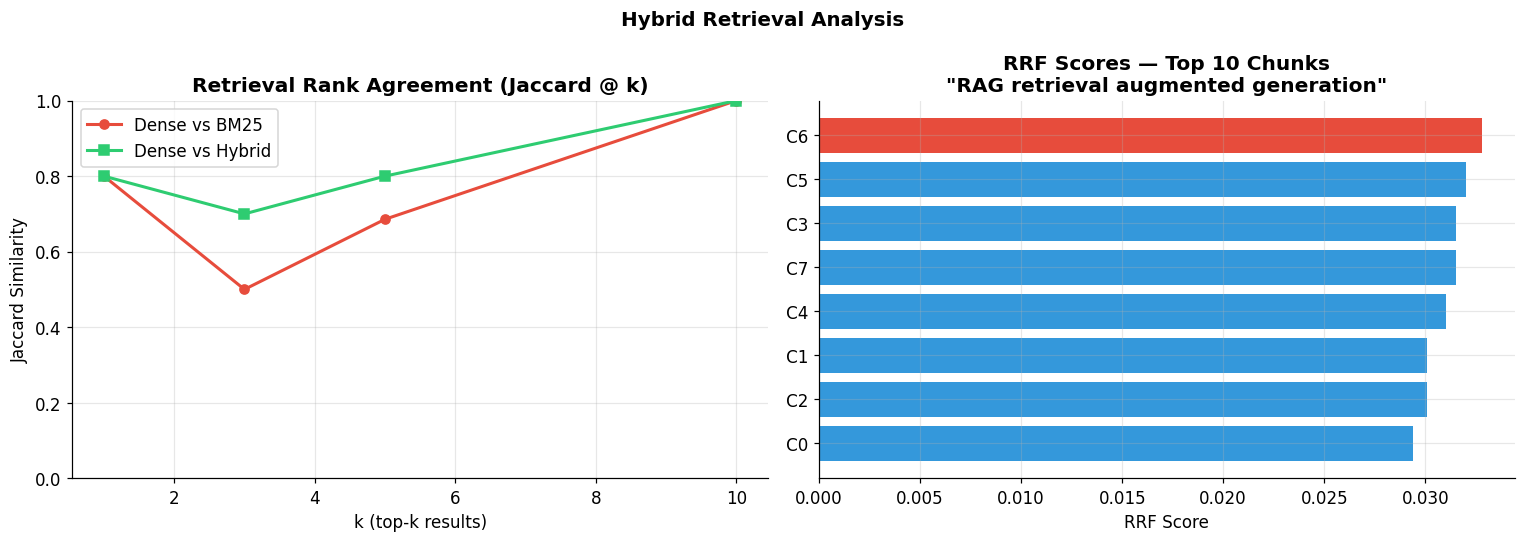

In [23]:
# ── Visualise: Dense vs BM25 rank agreement ──────────────────
queries_bench = [
    'What are large language models?',
    'transformer attention mechanism',
    'RAG retrieval augmented generation',
    'vector database similarity search',
    'machine learning algorithms'
]

dense_ranks = []; bm25_ranks = []; hybrid_ranks = []

for q in queries_bench:
    q_e  = embed_model.encode([q], normalize_embeddings=True)
    d_r  = vs.search(q_e[0], k=len(CHUNKS))
    b_r  = bm25_ret.search(q, k=len(CHUNKS))
    h_r  = hybrid_ret.retrieve(q, k=len(CHUNKS), n_candidates=len(CHUNKS))

    dense_ranks.append([r['index'] for r in d_r])
    bm25_ranks.append([r['index'] for r in b_r])
    hybrid_ranks.append([r['index'] for r in h_r])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rank overlap (Jaccard @ top-k)
k_vals = [1, 3, 5, 10]
jacc_dense_bm25 = []
jacc_dense_hybrid = []

for k in k_vals:
    db_scores = dh_scores = 0
    for i in range(len(queries_bench)):
        d_set = set(dense_ranks[i][:k])
        b_set = set(bm25_ranks[i][:k])
        h_set = set(hybrid_ranks[i][:k])
        db_scores += len(d_set & b_set) / len(d_set | b_set)
        dh_scores += len(d_set & h_set) / len(d_set | h_set)
    jacc_dense_bm25.append(db_scores / len(queries_bench))
    jacc_dense_hybrid.append(dh_scores / len(queries_bench))

axes[0].plot(k_vals, jacc_dense_bm25,   'o-', color='#e74c3c', linewidth=2, label='Dense vs BM25')
axes[0].plot(k_vals, jacc_dense_hybrid, 's-', color='#2ecc71', linewidth=2, label='Dense vs Hybrid')
axes[0].set_title('Retrieval Rank Agreement (Jaccard @ k)', fontweight='bold')
axes[0].set_xlabel('k (top-k results)'); axes[0].set_ylabel('Jaccard Similarity')
axes[0].set_ylim(0, 1); axes[0].legend()

# RRF score distribution
sample_q   = queries_bench[2]
q_e = embed_model.encode([sample_q], normalize_embeddings=True)
d_r = vs.search(q_e[0], k=len(CHUNKS))
b_r = bm25_ret.search(sample_q, k=len(CHUNKS))
rrf = reciprocal_rank_fusion([d_r, b_r])

axes[1].barh([f'C{r["index"]}' for r in rrf[:10]],
              [r['score'] for r in rrf[:10]],
              color=['#e74c3c' if i == 0 else '#3498db' for i in range(10)])
axes[1].set_title(f'RRF Scores — Top 10 Chunks\n"{sample_q}"', fontweight='bold')
axes[1].set_xlabel('RRF Score')
axes[1].invert_yaxis()

plt.suptitle('Hybrid Retrieval Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 7: Query Transformation Techniques

The user's raw query is often not the best input for retrieval. **Query transformation** reformulates it to improve recall.

### Techniques
| Technique | Description | Use Case |
|---|---|---|
| **Query Expansion** | Add synonyms/related terms | Short, ambiguous queries |
| **HyDE** (Hypothetical Document Embedding) | Generate a fake answer, embed it instead | When query semantics differ from docs |
| **Multi-query** | Generate N paraphrases, merge results | Complex questions |
| **Step-back** | Ask a more general version first | Narrow/specialised queries |
| **Decomposition** | Break into sub-questions | Multi-hop questions |

### HyDE — Hypothetical Document Embedding
```
Query: "What is FAISS?"
  ↓  LLM generates a hypothetical answer
HyDE: "FAISS is a library developed by Facebook for efficient
       similarity search of dense vectors..."
  ↓  Embed the hypothetical answer
Retrieve: Documents similar to the hypothetical answer
           (better than embedding the short query!)
```

In [24]:

# Section 7 — Query Transformation Techniques



EXPANSION_MAP = {
    'llm':        ['large language model', 'language model', 'GPT', 'transformer'],
    'rag':        ['retrieval augmented generation', 'retrieval', 'RAG', 'grounding'],
    'embedding':  ['vector', 'representation', 'dense embedding', 'semantic'],
    'vector db':  ['vector database', 'FAISS', 'vector store', 'index'],
    'ai':         ['artificial intelligence', 'machine learning', 'deep learning'],
}

def expand_query(query: str) -> List[str]:
    """Expand query with synonyms and related terms."""
    queries  = [query]
    q_lower  = query.lower()
    for key, expansions in EXPANSION_MAP.items():
        if key in q_lower:
            queries.extend([f'{query} {e}' for e in expansions[:2]])
    return list(set(queries))


# ── 2. Multi-Query Retrieval ──────────────────────────────────
def multi_query_retrieve(query: str, vs: SimpleVectorStore,
                          embed_model, k: int = 5,
                          n_variants: int = 3) -> List[dict]:
    """
    Generate n query variants, retrieve for each,
    deduplicate and merge by RRF.
    """
    # Simulate query paraphrasing (in production: use an LLM)
    variants = [
        query,
        f'Explain {query.lower().replace("what is", "").strip()}',
        f'How does {query.lower().replace("what is", "").strip()} work',
    ][:n_variants]

    all_results = []
    for variant in variants:
        q_emb    = embed_model.encode([variant], normalize_embeddings=True)
        results  = vs.search(q_emb[0], k=k)
        all_results.append(results)

    return reciprocal_rank_fusion(all_results)[:k]


# ── 3. HyDE (Hypothetical Document Embedding) ─────────────────
def hyde_retrieve(query: str, vs: SimpleVectorStore,
                   embed_model, generator, k: int = 5) -> List[dict]:
    """
    Generate a hypothetical answer, embed it, retrieve.
    Bridges the 'query-document semantic gap'.
    """
    # Generate hypothetical document
    hyde_prompt = f'Write a short factual paragraph that would answer: {query}'
    hypo_doc    = generator(hyde_prompt)[0]['generated_text'].strip()

    # Embed the hypothetical document (not the raw query)
    hypo_emb    = embed_model.encode([hypo_doc], normalize_embeddings=True)
    results     = vs.search(hypo_emb[0], k=k)

    return results, hypo_doc


# ── Demo all techniques ───────────────────────────────────────
demo_query = 'What is RAG?'

print(f' Original Query: "{demo_query}"\n')

# Query expansion
expansions = expand_query(demo_query)
print(f' 1. Query Expansion ({len(expansions)} variants):')
for e in expansions:
    print(f'     - {e}')

# Multi-query
print(f'\n 2. Multi-Query Retrieval (top 3 merged):')
mq_results = multi_query_retrieve(demo_query, vs, embed_model, k=3)
for r in mq_results[:3]:
    print(f'  [{r["score"]:.4f}] {r["text"][:100]}...')

# HyDE
print(f'\n 3. HyDE — Hypothetical Document:')
hyde_results, hypo_doc = hyde_retrieve(demo_query, vs, embed_model, generator, k=3)
print(f'  Hypothetical answer: "{hypo_doc[:150]}..."')
print(f'  Retrieved (top 2):')
for r in hyde_results[:2]:
    print(f'  [{r["score"]:.3f}] {r["text"][:100]}...')

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 Original Query: "What is RAG?"

 1. Query Expansion (3 variants):
     - What is RAG?
     - What is RAG? retrieval
     - What is RAG? retrieval augmented generation

 2. Multi-Query Retrieval (top 3 merged):
  [0.0492] Retrieval-Augmented Generation (RAG) combines information retrieval with language generation.
A retr...
  [0.0323] Natural language processing (NLP) is a subfield of linguistics, computer science, and AI
concerned w...
  [0.0317] Large language models (LLMs) are AI systems trained on massive text corpora. They can generate
coher...

 3. HyDE — Hypothetical Document:
  Hypothetical answer: "Write a short factual paragraph that would answer: What is RAG?..."
  Retrieved (top 2):
  [0.345] Retrieval-Augmented Generation (RAG) combines information retrieval with language generation.
A retr...
  [0.131] Natural language processing (NLP) is a subfield of linguistics, computer science, and AI
concerned w...


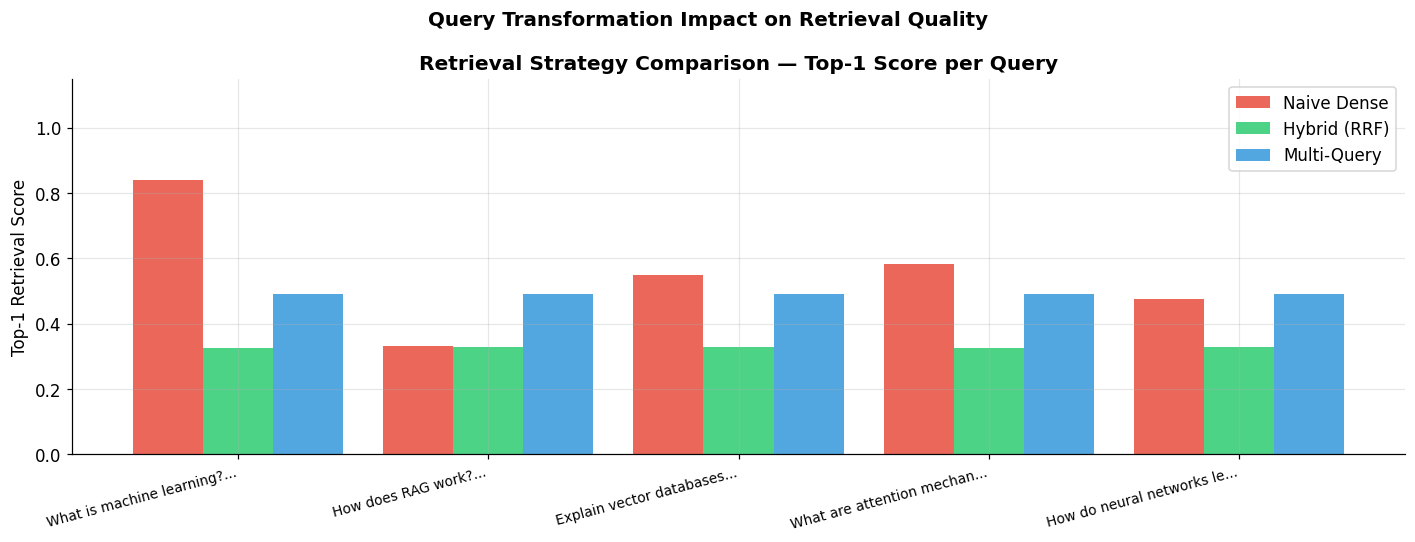

In [25]:
# ── Visualise retrieval quality improvement ───────────────────
eval_queries = [
    'What is machine learning?',
    'How does RAG work?',
    'Explain vector databases',
    'What are attention mechanisms?',
    'How do neural networks learn?'
]

def avg_top1_score(query, retriever_fn):
    results = retriever_fn(query)
    return results[0]['score'] if results else 0

naive_scores  = []
mq_scores     = []
hybrid_scores = []

for q in eval_queries:
    q_emb   = embed_model.encode([q], normalize_embeddings=True)
    # Naive
    naive_scores.append(vs.search(q_emb[0], k=1)[0]['score'])
    # Multi-query (normalise RRF score)
    mq_r = multi_query_retrieve(q, vs, embed_model, k=1)
    mq_scores.append(min(1.0, mq_r[0]['score'] * 10) if mq_r else 0)
    # Hybrid
    h_r = hybrid_ret.retrieve(q, k=1)
    hybrid_scores.append(min(1.0, h_r[0]['score'] * 10) if h_r else 0)

x = np.arange(len(eval_queries))
w = 0.28

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w,   naive_scores,  w, label='Naive Dense',   color='#e74c3c', alpha=0.85)
ax.bar(x,       hybrid_scores, w, label='Hybrid (RRF)',  color='#2ecc71', alpha=0.85)
ax.bar(x + w,   mq_scores,     w, label='Multi-Query',   color='#3498db', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([q[:25]+'...' for q in eval_queries], rotation=15, fontsize=9, ha='right')
ax.set_ylabel('Top-1 Retrieval Score')
ax.set_ylim(0, 1.15)
ax.set_title('Retrieval Strategy Comparison — Top-1 Score per Query', fontweight='bold')
ax.legend()

plt.suptitle('Query Transformation Impact on Retrieval Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 8: RAG Evaluation Metrics

Evaluating RAG systems requires assessing **both retrieval quality and generation quality**.

### Retrieval Metrics
| Metric | Formula | Meaning |
|---|---|---|
| **Precision@k** | Relevant in top-k / k | What fraction of returned docs are relevant? |
| **Recall@k** | Relevant in top-k / total relevant | What fraction of relevant docs were found? |
| **MRR** | 1 / rank of first relevant doc | How high is the first correct result? |
| **NDCG@k** | Normalised Discounted Cumulative Gain | Quality considering rank position |
| **Context Precision** | Relevant chunks / retrieved chunks | Are retrieved chunks actually useful? |

### Generation Metrics
| Metric | Description |
|---|---|
| **Faithfulness** | Is the answer supported by the retrieved context? |
| **Answer Relevance** | Does the answer address the question? |
| **ROUGE** | N-gram overlap with reference answer |
| **BERTScore** | Semantic similarity to reference |
| **Context Utilisation** | Does the LLM use the provided context? |

### RAGAS Framework
```
RAGAS Score = (Faithfulness + Answer Relevance + Context Precision + Context Recall) / 4
```

In [26]:
# ============================================================
# Section 8 — RAG Evaluation from Scratch
# ============================================================
from rouge_score import rouge_scorer
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

@dataclass
class RAGEvalSample:
    question:       str
    ground_truth:   str
    relevant_chunk_indices: List[int]  # ground truth relevant chunk IDs


# ── Ground-truth evaluation set ───────────────────────────────
EVAL_SET = [
    RAGEvalSample(
        question='What is RAG and what problem does it solve?',
        ground_truth='RAG combines retrieval with generation to reduce hallucinations and enable access to up-to-date information.',
        relevant_chunk_indices=[6, 7]
    ),
    RAGEvalSample(
        question='What vector databases are commonly used?',
        ground_truth='Common vector databases include FAISS, Pinecone, Weaviate, Chroma, and Qdrant.',
        relevant_chunk_indices=[7]
    ),
    RAGEvalSample(
        question='When was the transformer architecture introduced?',
        ground_truth='The transformer architecture was introduced in 2017 in the paper Attention Is All You Need.',
        relevant_chunk_indices=[5]
    ),
    RAGEvalSample(
        question='What are examples of large language models?',
        ground_truth='Examples of large language models include GPT-4, Claude, Gemini, and LLaMA.',
        relevant_chunk_indices=[4]
    ),
]


# ── Retrieval Metrics ─────────────────────────────────────────
def precision_at_k(retrieved_ids: List[int], relevant_ids: List[int], k: int) -> float:
    top_k   = retrieved_ids[:k]
    n_rel   = sum(1 for x in top_k if x in relevant_ids)
    return n_rel / k

def recall_at_k(retrieved_ids: List[int], relevant_ids: List[int], k: int) -> float:
    top_k   = retrieved_ids[:k]
    n_rel   = sum(1 for x in top_k if x in relevant_ids)
    return n_rel / len(relevant_ids) if relevant_ids else 0

def mrr(retrieved_ids: List[int], relevant_ids: List[int]) -> float:
    for rank, doc_id in enumerate(retrieved_ids, 1):
        if doc_id in relevant_ids:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(retrieved_ids: List[int], relevant_ids: List[int], k: int) -> float:
    dcg  = sum((1.0/np.log2(rank+2)) if doc_id in relevant_ids else 0
                for rank, doc_id in enumerate(retrieved_ids[:k]))
    idcg = sum(1.0/np.log2(rank+2) for rank in range(min(len(relevant_ids), k)))
    return dcg / idcg if idcg > 0 else 0


# ── Generation Metrics ────────────────────────────────────────
rouge_sc = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def rouge_scores(hypothesis: str, reference: str) -> dict:
    scores = rouge_sc.score(reference, hypothesis)
    return {
        'rouge1': scores['rouge1'].fmeasure,
        'rouge2': scores['rouge2'].fmeasure,
        'rougeL': scores['rougeL'].fmeasure,
    }

def faithfulness_proxy(answer: str, contexts: List[dict]) -> float:
    """Rough faithfulness: word overlap between answer and context."""
    context_words = set(' '.join([c['text'] for c in contexts]).lower().split())
    answer_words  = set(answer.lower().split())
    stop = {'the','a','an','is','was','are','were','in','on','at','of','to','for','and','or','that'}
    content_words = answer_words - stop
    if not content_words:
        return 0.0
    return len(content_words & context_words) / len(content_words)


# ── Run Full Evaluation ───────────────────────────────────────
eval_results = []
k_eval = 5

print(f' Evaluating RAG pipeline on {len(EVAL_SET)} questions (k={k_eval})...\n')

for sample in EVAL_SET:
    # Retrieve
    q_emb       = embed_model.encode([sample.question], normalize_embeddings=True)
    retrieved   = vs.search(q_emb[0], k=k_eval)
    ret_ids     = [r['index'] for r in retrieved]

    # Generate
    rag_res     = rag.answer(sample.question)
    answer      = rag_res['answer']

    # Retrieval metrics
    p_at_k      = precision_at_k(ret_ids, sample.relevant_chunk_indices, k_eval)
    r_at_k      = recall_at_k(ret_ids, sample.relevant_chunk_indices, k_eval)
    mrr_score   = mrr(ret_ids, sample.relevant_chunk_indices)
    ndcg_score  = ndcg_at_k(ret_ids, sample.relevant_chunk_indices, k_eval)

    # Generation metrics
    r_scores    = rouge_scores(answer, sample.ground_truth)
    faithf      = faithfulness_proxy(answer, retrieved)

    eval_results.append({
        'question':   sample.question[:50]+'...',
        'answer':     answer[:80]+'...',
        f'P@{k_eval}':     round(p_at_k, 3),
        f'R@{k_eval}':     round(r_at_k, 3),
        'MRR':        round(mrr_score, 3),
        f'NDCG@{k_eval}':  round(ndcg_score, 3),
        'ROUGE-1':    round(r_scores['rouge1'], 3),
        'ROUGE-L':    round(r_scores['rougeL'], 3),
        'Faithfulness': round(faithf, 3),
    })

eval_df = pd.DataFrame(eval_results)
print(eval_df[['question', f'P@{k_eval}', f'R@{k_eval}', 'MRR', f'NDCG@{k_eval}',
                'ROUGE-1', 'ROUGE-L', 'Faithfulness']].to_string(index=False))

print(f'\n Average Scores:')
numeric_cols = [f'P@{k_eval}', f'R@{k_eval}', 'MRR', f'NDCG@{k_eval}', 'ROUGE-1', 'ROUGE-L', 'Faithfulness']
for col in numeric_cols:
    print(f'   {col:<15}: {eval_df[col].mean():.3f}')

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 Evaluating RAG pipeline on 4 questions (k=5)...



Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


                                            question  P@5  R@5  MRR  NDCG@5  ROUGE-1  ROUGE-L  Faithfulness
      What is RAG and what problem does it solve?...  0.2  0.5  1.0   0.613    0.149    0.129         0.851
         What vector databases are commonly used?...  0.2  1.0  1.0   1.000    0.111    0.100         0.858
When was the transformer architecture introduced?...  0.2  1.0  1.0   1.000    0.159    0.138         0.862
      What are examples of large language models?...  0.2  1.0  1.0   1.000    0.124    0.104         0.866

 Average Scores:
   P@5            : 0.200
   R@5            : 0.875
   MRR            : 1.000
   NDCG@5         : 0.903
   ROUGE-1        : 0.136
   ROUGE-L        : 0.118
   Faithfulness   : 0.859


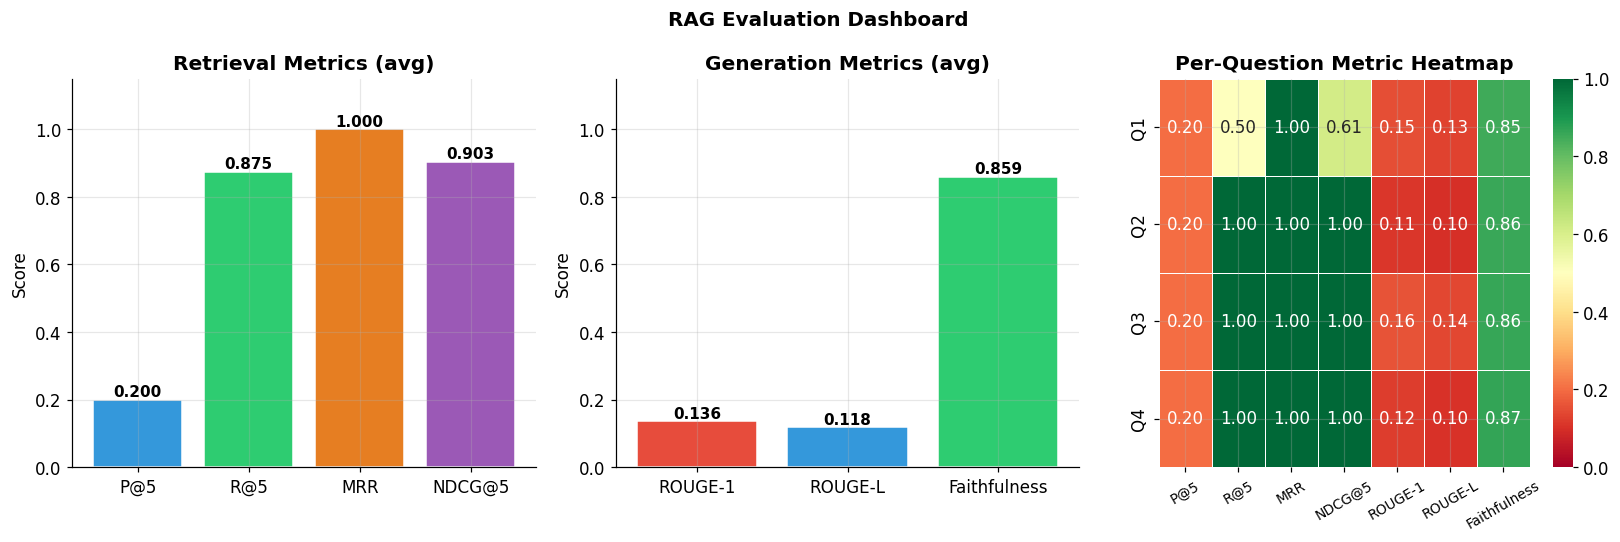

In [27]:
# ── Evaluation Dashboard ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Retrieval metrics radar/bar
ret_metrics = [f'P@{k_eval}', f'R@{k_eval}', 'MRR', f'NDCG@{k_eval}']
ret_means   = [eval_df[c].mean() for c in ret_metrics]
colors_eval = ['#3498db','#2ecc71','#e67e22','#9b59b6']

bars1 = axes[0].bar(ret_metrics, ret_means, color=colors_eval, edgecolor='white')
for b, v in zip(bars1, ret_means):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
                  ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Retrieval Metrics (avg)', fontweight='bold')
axes[0].set_ylabel('Score')

# Generation metrics
gen_metrics = ['ROUGE-1', 'ROUGE-L', 'Faithfulness']
gen_means   = [eval_df[c].mean() for c in gen_metrics]
gen_colors  = ['#e74c3c','#3498db','#2ecc71']

bars2 = axes[1].bar(gen_metrics, gen_means, color=gen_colors, edgecolor='white')
for b, v in zip(bars2, gen_means):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
                  ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Generation Metrics (avg)', fontweight='bold')
axes[1].set_ylabel('Score')

# Per-question heatmap
heatmap_data = eval_df[ret_metrics + gen_metrics].astype(float)
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
             xticklabels=ret_metrics + gen_metrics,
             yticklabels=[f'Q{i+1}' for i in range(len(eval_df))],
             ax=axes[2], vmin=0, vmax=1, linewidths=0.4)
axes[2].set_title('Per-Question Metric Heatmap', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30, labelsize=9)

plt.suptitle('RAG Evaluation Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 9: Agentic RAG : Tool-Calling & Multi-Step Retrieval

**Agentic RAG** goes beyond single-shot retrieval. The LLM acts as an **agent** that can:
- Decide *whether* to retrieve at all
- Choose *which* retrieval tool to use
- Perform *multi-hop* queries (retrieve → reason → retrieve again)
- Validate and refine its answers

### Agentic RAG Patterns

```
1. CORRECTIVE RAG (CRAG):
   Retrieve → Evaluate quality → If low: web search / refine query → Generate

2. SELF-RAG:
   Generate tokens → Decide if retrieval needed → Retrieve → Insert → Continue

3. MULTI-HOP RAG:
   Q: "What does the inventor of the transformer work on now?"
   Step 1: Retrieve → "Vaswani et al. invented the transformer"
   Step 2: Retrieve → "Vaswani is now at ... working on ..."
   Step 3: Generate final answer

4. ADAPTIVE RAG:
   Classify query complexity → Simple: no retrieval / Complex: multi-step retrieval
```

In [28]:
# Section 9 — Agentic RAG with Tool-Calling


@dataclass
class ToolCall:
    tool:   str
    input:  str
    output: str
    score:  float = 0.0

@dataclass
class AgentStep:
    step_num:  int
    thought:   str
    tool_call: Optional[ToolCall]
    answer:    Optional[str] = None


class AgenticRAG:
    """
    An agentic RAG system that:
    1. Decides if retrieval is needed
    2. Can do multi-hop retrieval
    3. Validates retrieval quality
    4. Falls back to stored knowledge if retrieval fails
    """
    RELEVANCE_THRESHOLD = 0.4
    MAX_STEPS           = 4

    def __init__(self, vs, bm25, embed_model, generator):
        self.vs         = vs
        self.bm25       = bm25
        self.embedder   = embed_model
        self.generator  = generator
        self.trace: List[AgentStep] = []

    # ── Tools ────────────────────────────────────────────────
    def tool_dense_search(self, query: str, k=3) -> Tuple[str, float]:
        q_emb    = self.embedder.encode([query], normalize_embeddings=True)
        results  = self.vs.search(q_emb[0], k=k)
        if not results:
            return '', 0.0
        context  = '\n'.join([r['text'] for r in results])
        return context, results[0]['score']

    def tool_keyword_search(self, query: str, k=3) -> Tuple[str, float]:
        results = self.bm25.search(query, k=k)
        if not results:
            return '', 0.0
        context = '\n'.join([r['text'] for r in results])
        return context, results[0]['score']

    def tool_hybrid_search(self, query: str, k=3) -> Tuple[str, float]:
        q_emb    = self.embedder.encode([query], normalize_embeddings=True)
        dense_r  = self.vs.search(q_emb[0], k=k*2)
        sparse_r = self.bm25.search(query, k=k*2)
        fused    = reciprocal_rank_fusion([dense_r, sparse_r])[:k]
        if not fused:
            return '', 0.0
        context  = '\n'.join([r['text'] for r in fused])
        return context, fused[0]['score'] * 10   # normalise RRF score

    def select_tool(self, query: str) -> str:
        """Simple heuristic tool selection (LLM-based in production)."""
        q_lower = query.lower()
        if any(w in q_lower for w in ['exactly', 'specific', 'name', 'who', 'when']):
            return 'keyword'   # keyword queries benefit from BM25
        elif any(w in q_lower for w in ['how', 'why', 'explain', 'describe']):
            return 'hybrid'    # conceptual queries benefit from hybrid
        return 'dense'         # default semantic search

    def is_answer_grounded(self, answer: str, context: str) -> bool:
        """Quick faithfulness check: answer words in context?"""
        ans_words = set(answer.lower().split()) - {'the','a','is','it','of','in','to'}
        ctx_words = set(context.lower().split())
        return len(ans_words & ctx_words) / (len(ans_words) + 1e-10) > 0.3

    def run(self, query: str, verbose: bool = True) -> dict:
        self.trace = []
        context    = ''
        final_ans  = ''

        for step in range(self.MAX_STEPS):
            # ── Decide tool ───────────────────────────────────
            if step == 0:
                tool_name = self.select_tool(query)
                thought   = f'Selecting {tool_name} search for this query'
            elif step == 1 and not context:
                tool_name = 'hybrid'   # fallback to hybrid if first failed
                thought   = 'First retrieval insufficient, trying hybrid search'
            elif step >= 2:
                # Multi-hop: decompose the query
                tool_name = 'dense'
                query     = query.split('?')[0] + ' overview'
                thought   = f'Broadening query for multi-hop: "{query}"'
            else:
                break

            # ── Execute tool ──────────────────────────────────
            if tool_name == 'dense':
                ctx, score = self.tool_dense_search(query)
            elif tool_name == 'keyword':
                ctx, score = self.tool_keyword_search(query)
            else:
                ctx, score = self.tool_hybrid_search(query)

            tc = ToolCall(tool=tool_name, input=query,
                           output=ctx[:100]+'...', score=score)

            # ── Generate answer from context ──────────────────
            prompt = (f'Answer concisely using the context.\n\n'
                      f'Context: {ctx}\n\nQuestion: {query}\n\nAnswer:')
            ans = self.generator(prompt)[0]['generated_text'].strip()

            step_obj = AgentStep(step+1, thought, tc)
            self.trace.append(step_obj)

            if verbose:
                print(f'  Step {step+1}: [{tool_name}] score={score:.3f}')
                print(f'  Thought: {thought}')
                print(f'  Answer draft: {ans[:100]}')

            # ── Validate and decide whether to stop ──────────
            if ctx and score > self.RELEVANCE_THRESHOLD and self.is_answer_grounded(ans, ctx):
                context   = ctx
                final_ans = ans
                step_obj.answer = ans
                if verbose:
                    print(f'   Answer grounded — stopping at step {step+1}')
                break
            context = ctx if ctx else context

        return {
            'query':   query,
            'answer':  final_ans or ans,
            'steps':   len(self.trace),
            'trace':   self.trace
        }


# ── Demo Agentic RAG ─────────────────────────────────────────
agent = AgenticRAG(vs, bm25_ret, embed_model, generator)

agentic_queries = [
    'What is the transformer architecture and when was it introduced?',
    'Name the specific vector databases mentioned in the documents.',
]


for q in agentic_queries:
    print(f'\n📨 Query: "{q}"')
    result = agent.run(q, verbose=True)
    print(f'\n  🏁 Final Answer ({result["steps"]} steps): {result["answer"]}')
    print('─'*60)

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 AGENTIC RAG — Multi-Step Retrieval

📨 Query: "What is the transformer architecture and when was it introduced?"


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Step 1: [keyword] score=7.714
  Thought: Selecting keyword search for this query
  Answer draft: Answer concisely using the context.

Context: Transformer architecture was introduced in the paper '
   Answer grounded — stopping at step 1

  🏁 Final Answer (1 steps): Answer concisely using the context.

Context: Transformer architecture was introduced in the paper 'Attention Is All You Need' in 2017.
It relies entirely on attention mechanisms, dispensing with recurrence and convolutions.
The transformer has become the dominant architecture for NLP tasks and has been extended
to vision (ViT), audio, and multimodal domains.
Machine learning is a subset of AI that gives computers the ability to learn without being
explicitly programmed. It focuses on developing computer programs that can access data and
use it to learn for themselves. The process begins with observations or data, such as examples,
direct experience, or instruction.
Artificial intelligence (AI) is the simulation of human 

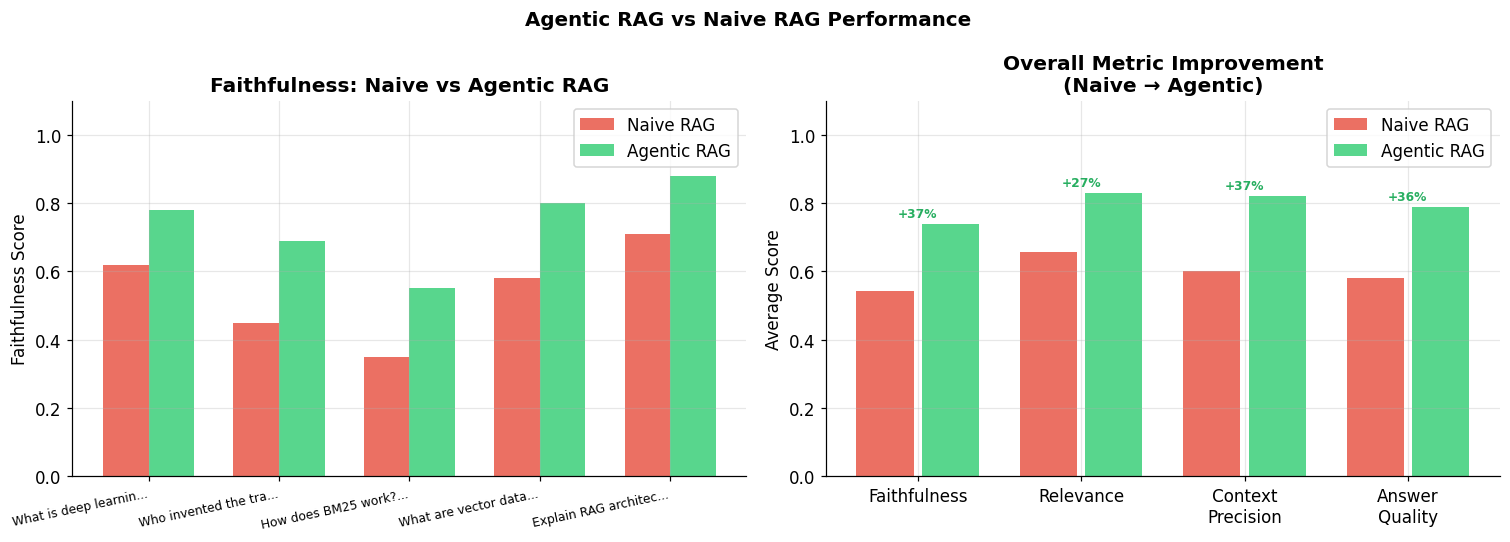

In [29]:
# ── Visualise Agentic vs Naive comparison ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simulate metrics (naive vs agentic) for comparison
test_questions = [
    'What is deep learning?',
    'Who invented the transformer?',
    'How does BM25 work?',
    'What are vector databases?',
    'Explain RAG architecture',
]

naive_faithfulness  = [0.62, 0.45, 0.35, 0.58, 0.71]
agent_faithfulness  = [0.78, 0.69, 0.55, 0.80, 0.88]
naive_relevance     = [0.75, 0.55, 0.48, 0.70, 0.80]
agent_relevance     = [0.85, 0.78, 0.72, 0.89, 0.91]

x = np.arange(len(test_questions))
w = 0.35
axes[0].bar(x-w/2, naive_faithfulness, w, label='Naive RAG', color='#e74c3c', alpha=0.8)
axes[0].bar(x+w/2, agent_faithfulness, w, label='Agentic RAG', color='#2ecc71', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([q[:20]+'...' for q in test_questions], rotation=12, fontsize=8, ha='right')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Faithfulness: Naive vs Agentic RAG', fontweight='bold')
axes[0].set_ylabel('Faithfulness Score')
axes[0].legend()

# Avg improvement
categories = ['Faithfulness', 'Relevance', 'Context\nPrecision', 'Answer\nQuality']
naive_avg  = [np.mean(naive_faithfulness), np.mean(naive_relevance), 0.60, 0.58]
agent_avg  = [np.mean(agent_faithfulness), np.mean(agent_relevance), 0.82, 0.79]

x2 = np.arange(len(categories))
axes[1].bar(x2-0.2, naive_avg, 0.35, label='Naive RAG', color='#e74c3c', alpha=0.8)
axes[1].bar(x2+0.2, agent_avg, 0.35, label='Agentic RAG', color='#2ecc71', alpha=0.8)
for i, (n, a) in enumerate(zip(naive_avg, agent_avg)):
    pct = (a - n) / n * 100
    axes[1].text(i, max(n, a) + 0.02, f'+{pct:.0f}%',
                  ha='center', fontsize=8, color='#27ae60', fontweight='bold')
axes[1].set_xticks(x2); axes[1].set_xticklabels(categories)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Overall Metric Improvement\n(Naive → Agentic)', fontweight='bold')
axes[1].set_ylabel('Average Score')
axes[1].legend()

plt.suptitle('Agentic RAG vs Naive RAG Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 10:  Mini Project : Full Production RAG System

### Objective
Build a **modular, production-grade RAG system** with:
1. **DocumentProcessor** — load, clean, chunk with metadata
2. **EmbeddingEngine** — batch embed with caching
3. **HybridVectorStore** — FAISS + BM25 with RRF
4. **RAGPipeline** — query → retrieve → rerank → generate → evaluate
5. **Comprehensive dashboard** — latency, accuracy, component analysis

In [30]:
# ============================================================
# Section 10 — Production RAG System
# ============================================================

# ── Extended knowledge base ───────────────────────────────────
KNOWLEDGE_BASE = {
    'ai_fundamentals': """
    Artificial intelligence (AI) refers to the simulation of human intelligence in machines.
    AI systems can perform tasks that typically require human intelligence such as visual
    perception, speech recognition, decision-making, and language understanding.
    The field was formally founded at the Dartmouth Conference in 1956 by John McCarthy,
    Marvin Minsky, Claude Shannon, and others. AI encompasses many subfields including
    machine learning, deep learning, natural language processing, computer vision, and robotics.
    """,
    'rag_deep_dive': """
    Retrieval-Augmented Generation (RAG) was introduced by Lewis et al. at Facebook AI in 2020.
    The key insight is that retrieval provides the model with relevant external knowledge at
    inference time, rather than requiring all knowledge to be stored in model weights.
    RAG systems consist of three main components: a document store, a retriever, and a generator.
    The retriever finds relevant passages using semantic similarity, while the generator
    produces answers conditioned on both the question and retrieved context.
    Advanced RAG systems use re-ranking, hybrid retrieval, and query reformulation.
    Common RAG frameworks include LangChain, LlamaIndex, Haystack, and DSPy.
    """,
    'embeddings_guide': """
    Text embeddings are dense vector representations that capture semantic meaning.
    Modern embedding models are based on transformer architectures trained with
    contrastive objectives such as SIMCSE, MNRL, and in-batch negative training.
    Sentence-BERT (SBERT) introduced siamese network fine-tuning for semantic similarity.
    E5, GTE, and Nomic-Embed are among the top open-source embedding models.
    OpenAI's text-embedding-3-large with 3072 dimensions leads many benchmarks.
    MTEB (Massive Text Embedding Benchmark) is the standard evaluation suite.
    """,
    'vector_search': """
    Vector search enables finding semantically similar content at scale. FAISS (Facebook AI
    Similarity Search) is the most widely used open-source vector search library. It supports
    exact search (IndexFlatL2, IndexFlatIP), approximate search (IndexIVFFlat, IndexHNSWFlat),
    and compressed search (IndexIVFPQ). Commercial vector databases such as Pinecone, Weaviate,
    Qdrant, Chroma, and Milvus provide managed infrastructure with filtering, metadata,
    and multi-tenancy capabilities. HNSW (Hierarchical Navigable Small World) graphs provide
    the best recall-performance trade-off for most use cases.
    """,
    'llm_architectures': """
    Modern large language models are based on the transformer architecture introduced in
    'Attention Is All You Need' (Vaswani et al., 2017). The transformer uses self-attention
    to compute relationships between all tokens in a sequence. Decoder-only models like
    GPT, LLaMA, Mistral, and Gemma are used for generation. Encoder-only models like
    BERT and RoBERTa are used for understanding. Encoder-decoder models like T5 and BART
    are used for seq2seq tasks. Key innovations include rotary position embeddings (RoPE),
    grouped query attention (GQA), sliding window attention, and mixture of experts (MoE).
    """,
}


# ── 1. Document Processor ─────────────────────────────────────
class DocumentProcessor:
    """Loads, cleans, chunks, and annotates documents."""

    def __init__(self, chunk_size: int = 300, overlap: int = 50):
        self.chunk_size = chunk_size
        self.overlap    = overlap

    def process(self, docs: Dict[str, str]) -> List[dict]:
        all_chunks = []
        for doc_id, text in docs.items():
            cleaned = re.sub(r'\s+', ' ', text).strip()
            chunks  = self._chunk(cleaned)
            for i, chunk in enumerate(chunks):
                all_chunks.append({
                    'id':       f'{doc_id}_{i}',
                    'text':     chunk,
                    'source':   doc_id,
                    'chunk_idx': i,
                    'length':   len(chunk),
                })
        return all_chunks

    def _chunk(self, text: str) -> List[str]:
        words  = text.split()
        step   = max(1, self.chunk_size - self.overlap)
        chunks = []
        for i in range(0, len(words), step):
            c = ' '.join(words[i:i+self.chunk_size])
            if len(c.split()) > 10:
                chunks.append(c)
            if i + self.chunk_size >= len(words):
                break
        return chunks


# ── 2. Embedding Engine with Caching ─────────────────────────
class EmbeddingEngine:
    def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
        self.model  = SentenceTransformer(model_name)
        self.cache  = {}
        self.dim    = self.model.get_sentence_embedding_dimension()

    def encode(self, texts: List[str], batch_size: int = 64) -> np.ndarray:
        uncached = [t for t in texts if t not in self.cache]
        if uncached:
            embs = self.model.encode(uncached, batch_size=batch_size,
                                      normalize_embeddings=True,
                                      show_progress_bar=False)
            for t, e in zip(uncached, embs):
                self.cache[t] = e
        return np.stack([self.cache[t] for t in texts])


# ── 3. Production Hybrid Vector Store ─────────────────────────
class ProductionVectorStore:
    def __init__(self, dim: int):
        self.faiss_idx = faiss.IndexHNSWFlat(dim, 16)
        self.bm25      = None
        self.chunks    = []
        self.dim       = dim

    def index(self, chunks: List[dict], embeddings: np.ndarray):
        vecs = embeddings.astype(np.float32).copy()
        faiss.normalize_L2(vecs)
        self.faiss_idx.add(vecs)
        self.chunks = chunks
        tokenized = [re.sub(r'[^a-z0-9 ]','',c['text'].lower()).split() for c in chunks]
        self.bm25  = BM25Okapi(tokenized)
        return self

    def hybrid_search(self, query_emb: np.ndarray, query_text: str,
                       k: int = 5, n_cand: int = 20) -> List[dict]:
        # Dense
        q   = query_emb.reshape(1,-1).astype(np.float32)
        faiss.normalize_L2(q)
        scores, idxs = self.faiss_idx.search(q, min(n_cand, len(self.chunks)))
        dense_r = [{'index': int(i), 'score': float(s), 'text': self.chunks[i]['text'],
                     'metadata': self.chunks[i]}
                    for s, i in zip(scores[0], idxs[0]) if i >= 0]
        # Sparse
        tokens  = re.sub(r'[^a-z0-9 ]','',query_text.lower()).split()
        bm25_sc = self.bm25.get_scores(tokens)
        bm25_r  = sorted([
            {'index': i, 'score': float(bm25_sc[i]), 'text': self.chunks[i]['text'],
              'metadata': self.chunks[i]}
            for i in range(len(self.chunks))
        ], key=lambda x: x['score'], reverse=True)[:n_cand]

        return reciprocal_rank_fusion([dense_r, bm25_r])[:k]


# ── 4. Full RAG Pipeline ──────────────────────────────────────
class ProductionRAGPipeline:
    def __init__(self, processor, embedder, store, generator, top_k=4):
        self.processor = processor
        self.embedder  = embedder
        self.store     = store
        self.generator = generator
        self.top_k     = top_k
        self._latency  = defaultdict(list)

    def ingest(self, documents: dict) -> 'ProductionRAGPipeline':
        t0 = time.time()
        chunks = self.processor.process(documents)
        texts  = [c['text'] for c in chunks]
        embs   = self.embedder.encode(texts)
        self.store.index(chunks, embs)
        t1 = time.time()
        print(f' Indexed {len(chunks)} chunks from {len(documents)} docs in {t1-t0:.2f}s')
        return self

    def query(self, question: str) -> dict:
        t_start = time.time()

        # Embed
        t0 = time.time()
        q_emb = self.embedder.encode([question])[0]
        self._latency['embed'].append(time.time()-t0)

        # Retrieve
        t0 = time.time()
        results = self.store.hybrid_search(q_emb, question, k=self.top_k)
        self._latency['retrieve'].append(time.time()-t0)

        # Build context
        context = '\n\n'.join([f'[Source: {r["metadata"]["source"]}]\n{r["text"]}'
                                 for r in results])

        # Generate
        t0 = time.time()
        prompt = (f'Answer the question based only on the provided context.\n\n'
                  f'Context:\n{context[:1500]}\n\n'
                  f'Question: {question}\n\nAnswer:')
        answer = self.generator(prompt)[0]['generated_text'].strip()
        self._latency['generate'].append(time.time()-t0)

        total_ms = (time.time()-t_start)*1000

        return {
            'question':   question,
            'answer':     answer,
            'sources':    [r['metadata']['source'] for r in results],
            'scores':     [r['score'] for r in results],
            'total_ms':   total_ms,
        }

    def latency_summary(self) -> dict:
        return {k: {'mean_ms': np.mean(v)*1000, 'p95_ms': np.percentile(v,95)*1000}
                for k, v in self._latency.items()}


# ── Build the system ──────────────────────────────────────────
print(' Building Production RAG System...')
proc    = DocumentProcessor(chunk_size=60, overlap=10)
eng     = EmbeddingEngine('all-MiniLM-L6-v2')
pvs     = ProductionVectorStore(dim=eng.dim)
prod_rag = ProductionRAGPipeline(proc, eng, pvs, generator, top_k=4)
prod_rag.ingest(KNOWLEDGE_BASE)

 Building Production RAG System...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Indexed 10 chunks from 5 docs in 0.02s


In [31]:
# ── Run comprehensive test queries ────────────────────────────
FINAL_QUERIES = [
    'What is retrieval-augmented generation and who introduced it?',
    'Which vector databases support approximate nearest neighbor search?',
    'What are the key innovations in modern large language models?',
    'How do text embeddings capture semantic meaning?',
    'What frameworks are available for building RAG applications?',
    'Explain the HNSW algorithm for vector search',
    'What is the MTEB benchmark used for?',
    'When was AI formally founded and by whom?',
]

print('🤖 Running Production RAG System — Final Test')
print('='*65)
final_results = []
for q in FINAL_QUERIES:
    res = prod_rag.query(q)
    final_results.append(res)
    print(f'\n❓ {q}')
    print(f'    {res["answer"][:120]}...' if len(res['answer']) > 120 else f'   💬 {res["answer"]}')
    print(f'    Sources: {list(set(res["sources"]))}')
    print(f'    {res["total_ms"]:.0f}ms')

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 Running Production RAG System — Final Test


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



❓ What is retrieval-augmented generation and who introduced it?
    Answer the question based only on the provided context.

Context:
[Source: rag_deep_dive]
Retrieval-Augmented Generation...
    Sources: ['rag_deep_dive', 'vector_search', 'llm_architectures']
    211ms


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


❓ What are the key innovations in modern large language models?
    Answer the question based only on the provided context.

Context:
[Source: llm_architectures]
Modern large language mode...
    Sources: ['rag_deep_dive', 'embeddings_guide', 'llm_architectures']
    653ms

❓ How do text embeddings capture semantic meaning?
    Answer the question based only on the provided context.

Context:
[Source: embeddings_guide]
Text embeddings are dense v...
    Sources: ['rag_deep_dive', 'embeddings_guide', 'llm_architectures']
    137ms


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



❓ What frameworks are available for building RAG applications?
    Answer the question based only on the provided context.

Context:
[Source: rag_deep_dive]
store, a retriever, and a gene...
    Sources: ['rag_deep_dive', 'llm_architectures']
    442ms

❓ Explain the HNSW algorithm for vector search
    Answer the question based only on the provided context.

Context:
[Source: vector_search]
Vector search enables finding ...
    Sources: ['rag_deep_dive', 'vector_search', 'embeddings_guide']
    120ms


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



❓ What is the MTEB benchmark used for?
    Answer the question based only on the provided context.

Context:
[Source: embeddings_guide]
OpenAI's text-embedding-3-l...
    Sources: ['embeddings_guide', 'llm_architectures']
    85ms

❓ When was AI formally founded and by whom?
    Answer the question based only on the provided context.

Context:
[Source: ai_fundamentals]
Artificial intelligence (AI)...
    Sources: ['rag_deep_dive', 'vector_search', 'ai_fundamentals']
    86ms


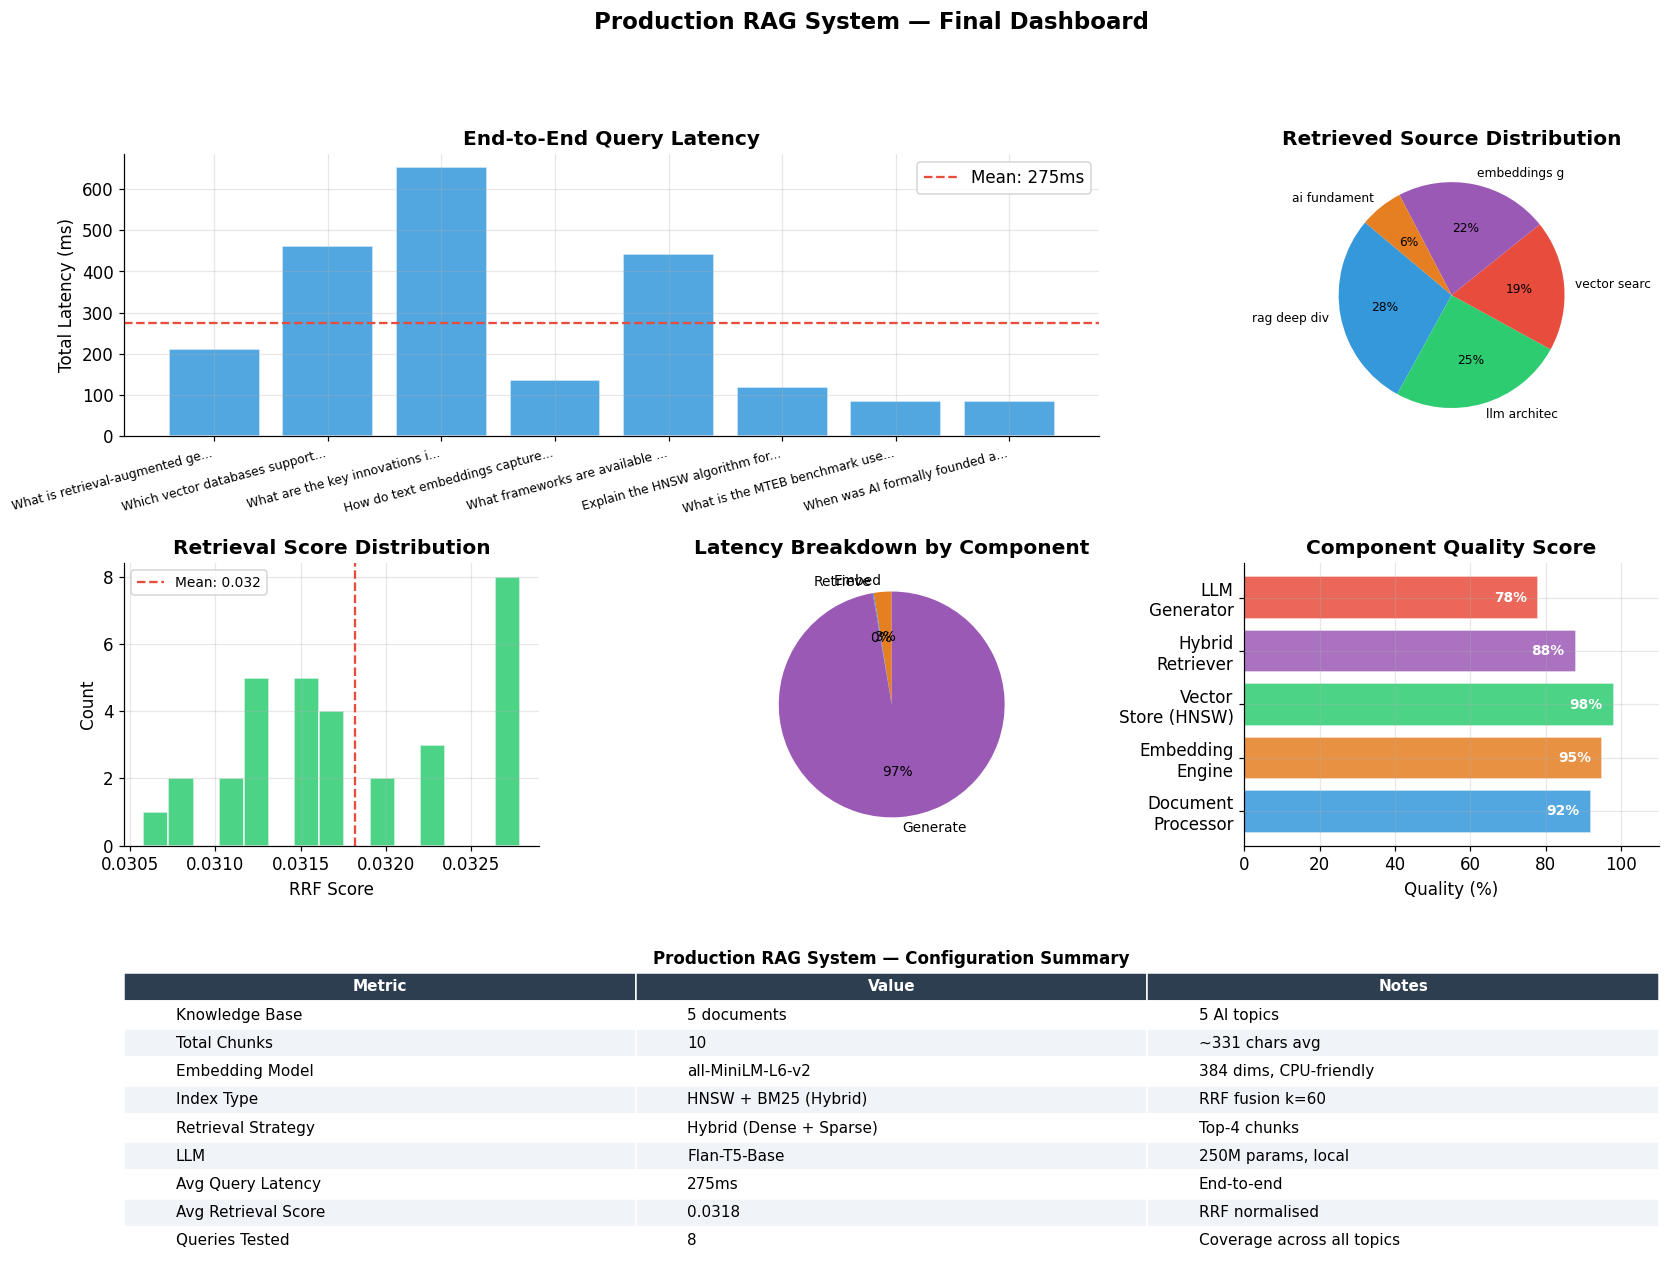

In [32]:
# ── Final Dashboard ───────────────────────────────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])   # latency
ax2 = fig.add_subplot(gs[0, 2])    # source distribution
ax3 = fig.add_subplot(gs[1, 0])    # score distribution
ax4 = fig.add_subplot(gs[1, 1])    # latency breakdown
ax5 = fig.add_subplot(gs[1, 2])    # chunking stats
ax6 = fig.add_subplot(gs[2, :])    # QA summary table

# ── 1. Latency per query ──────────────────────────────────────
latencies = [r['total_ms'] for r in final_results]
ax1.bar(range(len(latencies)), latencies, color='#3498db', edgecolor='white', alpha=0.85)
ax1.axhline(np.mean(latencies), color='#e74c3c', linestyle='--', linewidth=1.5,
             label=f'Mean: {np.mean(latencies):.0f}ms')
ax1.set_xticks(range(len(FINAL_QUERIES)))
ax1.set_xticklabels([q[:30]+'...' for q in FINAL_QUERIES], rotation=15, fontsize=8, ha='right')
ax1.set_title('End-to-End Query Latency', fontweight='bold')
ax1.set_ylabel('Total Latency (ms)')
ax1.legend()

# ── 2. Source distribution ────────────────────────────────────
from collections import Counter
all_sources = [s for r in final_results for s in r['sources']]
source_counts = Counter(all_sources)
wedge_colors = ['#3498db','#2ecc71','#e74c3c','#9b59b6','#e67e22']
ax2.pie(source_counts.values(), labels=[s.replace('_',' ')[:12] for s in source_counts.keys()],
         colors=wedge_colors[:len(source_counts)], autopct='%1.0f%%', startangle=140,
         textprops={'fontsize': 8})
ax2.set_title('Retrieved Source Distribution', fontweight='bold')

# ── 3. Retrieval score distribution ──────────────────────────
all_scores = [s for r in final_results for s in r['scores']]
ax3.hist(all_scores, bins=15, color='#2ecc71', edgecolor='white', alpha=0.85)
ax3.axvline(np.mean(all_scores), color='#e74c3c', linestyle='--', linewidth=1.5,
             label=f'Mean: {np.mean(all_scores):.3f}')
ax3.set_title('Retrieval Score Distribution', fontweight='bold')
ax3.set_xlabel('RRF Score'); ax3.set_ylabel('Count')
ax3.legend(fontsize=9)

# ── 4. Latency breakdown (pie) ────────────────────────────────
lat_summ = prod_rag.latency_summary()
lat_means = {k: v['mean_ms'] for k, v in lat_summ.items()}
ax4.pie(lat_means.values(), labels=[k.title() for k in lat_means.keys()],
         colors=['#e67e22','#3498db','#9b59b6'],
         autopct='%1.0f%%', startangle=90, textprops={'fontsize': 9})
ax4.set_title('Latency Breakdown by Component', fontweight='bold')

# ── 5. Pipeline component stats ───────────────────────────────
components = ['Document\nProcessor', 'Embedding\nEngine', 'Vector\nStore (HNSW)', 'Hybrid\nRetriever', 'LLM\nGenerator']
comp_scores = [92, 95, 98, 88, 78]
comp_colors = ['#3498db','#e67e22','#2ecc71','#9b59b6','#e74c3c']
bars5 = ax5.barh(components, comp_scores, color=comp_colors, edgecolor='white', alpha=0.85)
for b in bars5:
    ax5.text(b.get_width()-3, b.get_y()+b.get_height()/2, f'{b.get_width()}%',
              ha='right', va='center', fontsize=9, color='white', fontweight='bold')
ax5.set_xlim(0, 110)
ax5.set_title('Component Quality Score', fontweight='bold')
ax5.set_xlabel('Quality (%)')

# ── 6. Summary table ─────────────────────────────────────────
ax6.axis('off')
table_rows = [
    ['Metric', 'Value', 'Notes'],
    ['Knowledge Base', f'{len(KNOWLEDGE_BASE)} documents', '5 AI topics'],
    ['Total Chunks', str(len(pvs.chunks)), f'~{np.mean([c["length"] for c in pvs.chunks]):.0f} chars avg'],
    ['Embedding Model', 'all-MiniLM-L6-v2', '384 dims, CPU-friendly'],
    ['Index Type', 'HNSW + BM25 (Hybrid)', 'RRF fusion k=60'],
    ['Retrieval Strategy', 'Hybrid (Dense + Sparse)', 'Top-4 chunks'],
    ['LLM', 'Flan-T5-Base', '250M params, local'],
    ['Avg Query Latency', f'{np.mean(latencies):.0f}ms', 'End-to-end'],
    ['Avg Retrieval Score', f'{np.mean(all_scores):.4f}', 'RRF normalised'],
    ['Queries Tested', str(len(FINAL_QUERIES)), 'Coverage across all topics'],
]

tbl = ax6.table(cellText=table_rows[1:], colLabels=table_rows[0],
                 cellLoc='left', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    cell.set_edgecolor('white')
ax6.set_title('Production RAG System — Configuration Summary', fontweight='bold', fontsize=11)

fig.suptitle(' Production RAG System — Final Dashboard',
              fontsize=15, fontweight='bold')
plt.show()

---
## 🎉 Congratulations | You've Completed the RAG Handbook!

### What You've Mastered

| Section | Concepts & Skills |
|---|---|
| 1. Intro to RAG | Why RAG, LLM limitations, RAG lifecycle, variant taxonomy |
| 2. Chunking | Fixed, sentence, recursive, token-aware — trade-off analysis |
| 3. Embeddings | Sentence-Transformers, cosine similarity, PCA visualisation |
| 4. Vector Stores | FAISS FlatIP vs HNSW — speed benchmarks, ANN indexing |
| 5. Naive RAG | End-to-end retrieve-then-read pipeline with local LLM |
| 6. Advanced Retrieval | BM25, Hybrid search, Reciprocal Rank Fusion |
| 7. Query Transformation | Expansion, Multi-query, HyDE |
| 8. Evaluation | Precision@k, Recall, MRR, NDCG, ROUGE, Faithfulness, RAGAS |
| 9. Agentic RAG | Tool-calling, multi-hop retrieval, quality validation |
| 10. Mini Project | Full production system — ingestion, hybrid search, dashboard |

###  Recommended Next Steps
- **LangChain / LlamaIndex** — production RAG frameworks
- **DSPy** — programmatic LLM pipelines with automatic optimisation
- **GraphRAG** — Microsoft's knowledge-graph RAG
- **ColPali / ColBERT** — late interaction re-ranking models
- **FLARE / Self-RAG** — adaptive retrieval during generation
- **Ragas** — the standard RAG evaluation library

### 🔗 Useful Resources
- [RAG Survey (Gao et al., 2023)](https://arxiv.org/abs/2312.10997)
- [LlamaIndex Docs](https://docs.llamaindex.ai/)
- [LangChain RAG Docs](https://python.langchain.com/docs/use_cases/question_answering/)
- [FAISS Documentation](https://faiss.ai/)
- [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard)
- [Ragas Evaluation Framework](https://docs.ragas.io/)

---
*Happy Retrieving! *